# 01 — GLO Dataset Inspection

**Project:** GlacierGuard AI  
**Dataset:** Glacial Lake Observatory (GLO) — Nepal & Transboundary Catchments (2017–2024) v1.02  
**Source:** Rawlins et al. (2025) — Zenodo: https://doi.org/10.5281/zenodo.17802333  

---

This notebook performs a **read-only** inspection of the two GLO GeoPackage files placed in `raw/GLO/`.  
No modifications are made to the original dataset files.

### Files on disk
| Filename | Sensor | Description |
|---|---|---|
| `S1_20172024_NTB_GLOID_UniqueLakesv1.02.gpkg` | Sentinel-1 (SAR) | Dissolved unique lake polygons |
| `S2_20172024_NTB_GLOID_UniqueLakes_v1.02.gpkg` | Sentinel-2 (Optical) | Dissolved unique lake polygons |

In [1]:
# == Imports ==
import os
import pathlib

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

print(f'GeoPandas  : {gpd.__version__}')
print(f'Pandas     : {pd.__version__}')

GeoPandas  : 1.1.4
Pandas     : 2.2.2


In [2]:
# == Path setup ==
# Notebook lives in notebooks/, dataset files are in raw/GLO/
GLO_DIR = pathlib.Path('../raw/GLO')

S1_PATH = GLO_DIR / 'S1_20172024_NTB_GLOID_UniqueLakesv1.02.gpkg'
S2_PATH = GLO_DIR / 'S2_20172024_NTB_GLOID_UniqueLakes_v1.02.gpkg'

print('S1 file exists:', S1_PATH.exists(), '|', S1_PATH.stat().st_size / 1e6, 'MB')
print('S2 file exists:', S2_PATH.exists(), '|', S2_PATH.stat().st_size / 1e6, 'MB')

S1 file exists: True | 7.000064 MB
S2 file exists: True | 7.835648 MB


## 1 — Load GeoPackages

In [3]:
s1 = gpd.read_file(S1_PATH)
s2 = gpd.read_file(S2_PATH)
print(f'S1 loaded: {len(s1):,} features')
print(f'S2 loaded: {len(s2):,} features')

S1 loaded: 2,967 features
S2 loaded: 4,150 features


## 2 — Coordinate Reference System (CRS)

In [4]:
for label, gdf in [('Sentinel-1', s1), ('Sentinel-2', s2)]:
    crs = gdf.crs
    print(f'=== {label} ===')
    print(f'  CRS name  : {crs.name}')
    print(f'  Auth code : {crs.to_authority()}')
    print()

=== Sentinel-1 ===
  CRS name  : Asia_North_Albers_Equal_Area_Conic
  Auth code : ('ESRI', '102025')

=== Sentinel-2 ===
  CRS name  : Asia_North_Albers_Equal_Area_Conic
  Auth code : ('ESRI', '102025')



## 3 — Geometry Type

In [5]:
for label, gdf in [('Sentinel-1', s1), ('Sentinel-2', s2)]:
    geom_types = gdf.geometry.geom_type.value_counts()
    print(f'=== {label} geometry types ===')
    print(geom_types.to_string())
    print()

=== Sentinel-1 geometry types ===
MultiPolygon    2967

=== Sentinel-2 geometry types ===
MultiPolygon    4150



## 4 — Column Schema

In [6]:
for label, gdf in [('Sentinel-1', s1), ('Sentinel-2', s2)]:
    print('=' * 60)
    print(f'{label} UNIQUE LAKES — Column Schema')
    print('=' * 60)
    for col, dtype in zip(gdf.columns, gdf.dtypes):
        print(f'  {col:<35} {str(dtype)}')
    print()

Sentinel-1 UNIQUE LAKES — Column Schema
  GLO_ID                              object
  COUNTRY                             object
  BASIN                               object
  CONNECTIVITY                        object
  DATA_SOURCE                         object
  EXPANSION_RATE                      float64
  EXPANSION_UNCERTAINTY               float64
  EXPANSION_RATE_SIG                  object
  S2_MSTAT                            float64
  LONGITUDE                           float64
  LATITUDE                            float64
  GTNG_REGION_O2                      object
  ELEVATION_MIN                       float64
  ELEVATION_MEDIAN                    float64
  ELEVATION_MEAN                      float64
  AREA_DISSOLVED                      float64
  PERIMETER_DISSOLVED                 float64
  geometry                            geometry

Sentinel-2 UNIQUE LAKES — Column Schema
  GLO_ID                              object
  COUNTRY                             object
  BASIN

In [7]:
s1_cols = set(s1.columns)
s2_cols = set(s2.columns)
print('Columns in S1 but NOT in S2:', s1_cols - s2_cols)
print('Columns in S2 but NOT in S1:', s2_cols - s1_cols)
print('Columns common to both      :', len(s1_cols & s2_cols), 'columns')

Columns in S1 but NOT in S2: {'S2_MSTAT'}
Columns in S2 but NOT in S1: {'REF_MSTAT'}
Columns common to both      : 17 columns


## Column Descriptions (from GLO README)

| Field | Description |
|---|---|
| `GLO_ID` | **Primary unique identifier** — encodes lake position as `GLO_lon_lat` |
| `COUNTRY` | Country where the lake is located |
| `BASIN` | Hydrological basin name |
| `CONNECTIVITY` | Whether the lake is glacier-fed or non-glacier-fed |
| `ELEVATION_MEAN` | Mean lake-surface elevation (m, ALOS AW3D30 DEM) |
| `ELEVATION_MIN` | Minimum elevation (m) |
| `ELEVATION_MEDIAN` | Median elevation (m) |
| `LONGITUDE` | Representative lake centre longitude (decimal degrees) |
| `LATITUDE` | Representative lake centre latitude (decimal degrees) |
| `DATA_SOURCE` | Satellite sensor (Sentinel-1 / Sentinel-2) |
| `START_DATE` | Start date of observation period |
| `END_DATE` | End date of observation period |
| `GTNG_REGION` | GTN-G region code (02 = High Mountain Asia) |
| `TS_OUTLIER` | Boolean — marks temporal outlier in time series |
| `AREA_DISSOLVED` | Total dissolved lake area (km²) across all years |
| `PERIMETER_DISSOLVED` | Perimeter of dissolved maximum extent (km) |
| `EXPANSION_RATE` | Lake area change rate 2017–2024 (km² yr⁻¹) |
| `EXPANSION_UNCERTAINTY` | Uncertainty in expansion rate (km² yr⁻¹) |
| `EXPANSION_RATE_SIG` | Boolean — whether expansion is statistically significant |
| `S2_MSTAT` | Whether this S1 lake matches an S2 lake (S1 file only) |
| `geometry` | Polygon geometry (dissolved maximum lake extent) |

## 5 — First 5 Records

In [8]:
print('=== Sentinel-1 — head(5) ===')
display(s1.drop(columns='geometry').head())

=== Sentinel-1 — head(5) ===


,GLO_ID,COUNTRY,BASIN,CONNECTIVITY,DATA_SOURCE,EXPANSION_RATE,EXPANSION_UNCERTAINTY,EXPANSION_RATE_SIG,S2_MSTAT,LONGITUDE,LATITUDE,GTNG_REGION_O2,ELEVATION_MIN,ELEVATION_MEDIAN,ELEVATION_MEAN,AREA_DISSOLVED,PERIMETER_DISSOLVED
0,GLO_80.03311_30.32452,India,Karnali,Glacier-fed,Sentinel-1,0.0000,0.0000,None,0.0,80.03311,30.32452,15-01,4887.0,4888.483007,4888.430176,0.008259,0.429067
1,GLO_80.04206_30.3709,India,Karnali,Glacier-fed,Sentinel-1,0.0000,0.0000,None,1.0,80.04200,30.37087,15-01,4589.0,4608.617580,4607.427734,0.008255,0.471461
2,GLO_80.05413_30.37819,India,Karnali,Glacier-fed,Sentinel-1,0.0000,0.0000,None,0.0,80.05413,30.37819,15-01,4504.0,4509.000000,4513.311523,0.001290,0.166014
3,GLO_80.05556_30.37113,India,Karnali,Glacier-fed,Sentinel-1,0.0000,0.0000,None,0.0,80.05556,30.37113,15-01,4476.0,4476.500000,4476.208984,0.008269,0.547027
4,GLO_80.07262_30.33587,India,Karnali,Glacier-fed,Sentinel-1,0.0041,0.0057,FALSE,1.0,80.07299,30.33669,15-01,4191.0,4201.754220,4206.367676,0.080575,1.709878


In [9]:
print('=== Sentinel-2 — head(5) ===')
display(s2.drop(columns='geometry').head())

=== Sentinel-2 — head(5) ===


,GLO_ID,COUNTRY,BASIN,CONNECTIVITY,ELEVATION_MEAN,ELEVATION_MIN,ELEVATION_MEDIAN,DATA_SOURCE,REF_MSTAT,LONGITUDE,LATITUDE,GTNG_REGION_O2,EXPANSION_RATE,EXPANSION_UNCERTAINTY,EXPANSION_RATE_SIG,AREA_DISSOLVED,PERIMETER_DISSOLVED
0,GLO_80.04206_30.3709,India,Karnali,Glacier-fed,4606.184082,4589.0,4606.044971,Sentinel-2,dl_new,80.04206,30.37090,15-01,0.0000,0.0000,None,0.008146,0.485041
1,GLO_80.05083_30.54339,India,Karnali,Non Glacier-fed,4618.577148,4610.0,4617.768531,Sentinel-2,dl_new,80.05083,30.54339,15-01,0.0000,0.0000,None,0.002660,0.295060
2,GLO_80.07074_30.5746,India,Karnali,Glacier-fed,5059.776367,5049.0,5057.523129,Sentinel-2,dl_new,80.07074,30.57460,15-01,0.0000,0.0000,None,0.002577,0.292571
3,GLO_80.07262_30.33587,India,Karnali,Glacier-fed,4219.072266,4203.0,4219.111548,Sentinel-2,NA,80.07262,30.33587,15-01,0.0038,0.0014,TRUE,0.033167,0.950797
4,GLO_80.07563_30.51573,India,Karnali,Glacier-fed,4128.408203,4127.0,4128.390832,Sentinel-2,dl_new,80.07563,30.51573,15-01,0.0000,0.0000,None,0.004738,0.360732


## 6 — Numeric Summary Statistics

In [10]:
numeric_cols = ['AREA_DISSOLVED', 'PERIMETER_DISSOLVED', 'EXPANSION_RATE',
                'EXPANSION_UNCERTAINTY', 'ELEVATION_MEAN', 'ELEVATION_MIN',
                'ELEVATION_MEDIAN', 'LONGITUDE', 'LATITUDE']

for label, gdf in [('Sentinel-1', s1), ('Sentinel-2', s2)]:
    cols_present = [c for c in numeric_cols if c in gdf.columns]
    print(f'=== {label} — Numeric Summary ===')
    display(gdf[cols_present].describe().round(4))
    print()

=== Sentinel-1 — Numeric Summary ===


,AREA_DISSOLVED,PERIMETER_DISSOLVED,EXPANSION_RATE,EXPANSION_UNCERTAINTY,ELEVATION_MEAN,ELEVATION_MIN,ELEVATION_MEDIAN,LONGITUDE,LATITUDE
count,2967.0000,2967.0000,2967.0000,2967.0000,2967.0000,2967.0000,2967.0000,2967.0000,2967.0000
mean,0.0645,1.0353,0.0003,0.0016,5028.9074,5023.5511,5028.6428,85.3119,28.6645
std,0.2227,1.2334,0.0050,0.0064,455.3940,455.8217,455.3937,2.2959,0.8399
min,0.0010,0.1479,-0.1151,0.0000,1996.8167,1996.0000,1996.5000,80.0331,27.4752
25%,0.0079,0.4489,-0.0002,0.0000,4744.0364,4736.0000,4743.4041,83.0358,28.0020
50%,0.0187,0.6958,0.0000,0.0005,5091.4263,5083.0000,5091.4162,86.2368,28.3093
75%,0.0467,1.1554,0.0002,0.0012,5373.9236,5372.0000,5374.0671,87.3051,29.2177
max,5.4871,16.9130,0.1012,0.1582,6035.6606,6024.0000,6035.4611,88.8812,30.5889



=== Sentinel-2 — Numeric Summary ===


,AREA_DISSOLVED,PERIMETER_DISSOLVED,EXPANSION_RATE,EXPANSION_UNCERTAINTY,ELEVATION_MEAN,ELEVATION_MIN,ELEVATION_MEDIAN,LONGITUDE,LATITUDE
count,4150.0000,4150.0000,4144.0000,4144.0000,4150.0000,4150.0000,4150.0000,4150.0000,4150.0000
mean,0.0502,0.9168,0.0003,0.0008,5029.9711,5024.0217,5029.7515,85.2260,28.6621
std,0.1937,1.1330,0.0027,0.0021,476.8086,476.6357,476.7438,2.2854,0.8390
min,0.0011,0.1436,-0.0372,0.0000,1973.1703,1930.0000,1973.1509,80.0421,27.4753
25%,0.0060,0.4020,0.0000,0.0000,4743.2163,4737.0000,4742.5413,83.0040,27.9993
50%,0.0141,0.6145,0.0000,0.0003,5090.9578,5086.0000,5091.4408,86.1227,28.3112
75%,0.0338,0.9883,0.0001,0.0008,5374.8734,5370.0000,5374.1375,87.1730,29.2328
max,5.5320,18.2640,0.0820,0.0578,7381.2002,7285.0000,7384.3133,88.7875,30.5809


## 7 — GLO_ID Uniqueness Check

In [11]:
for label, gdf in [('Sentinel-1', s1), ('Sentinel-2', s2)]:
    total = len(gdf)
    unique_ids = gdf['GLO_ID'].nunique()
    null_ids   = gdf['GLO_ID'].isna().sum()
    print(f'=== {label} ===')
    print(f'  Total features : {total:,}')
    print(f'  Unique GLO_IDs : {unique_ids:,}')
    print(f'  Null GLO_IDs   : {null_ids}')
    print(f'  GLO_ID is unique per row: {unique_ids == total}')
    print(f'  Sample GLO_IDs: {gdf["GLO_ID"].dropna().head(3).tolist()}')
    print()

=== Sentinel-1 ===
  Total features : 2,967
  Unique GLO_IDs : 2,967
  Null GLO_IDs   : 0
  GLO_ID is unique per row: True
  Sample GLO_IDs: ['GLO_80.03311_30.32452', 'GLO_80.04206_30.3709', 'GLO_80.05413_30.37819']

=== Sentinel-2 ===
  Total features : 4,150
  Unique GLO_IDs : 4,150
  Null GLO_IDs   : 0
  GLO_ID is unique per row: True
  Sample GLO_IDs: ['GLO_80.04206_30.3709', 'GLO_80.05083_30.54339', 'GLO_80.07074_30.5746']



## 8 — Geographic Coverage

In [12]:
for label, gdf in [('Sentinel-1', s1), ('Sentinel-2', s2)]:
    gdf_wgs = gdf.to_crs(epsg=4326)
    bounds  = gdf_wgs.total_bounds
    print(f'=== {label} — Bounding Box (WGS84) ===')
    print(f'  Longitude range : {bounds[0]:.4f}° → {bounds[2]:.4f}°')
    print(f'  Latitude  range : {bounds[1]:.4f}° → {bounds[3]:.4f}°')
    print()

=== Sentinel-1 — Bounding Box (WGS84) ===
  Longitude range : 80.0326° → 88.8817°
  Latitude  range : 27.4744° → 30.5899°

=== Sentinel-2 — Bounding Box (WGS84) ===
  Longitude range : 80.0416° → 88.7885°
  Latitude  range : 27.4744° → 30.5817°



In [13]:
for label, gdf in [('Sentinel-1', s1), ('Sentinel-2', s2)]:
    print(f'=== {label} — Lakes by COUNTRY ===')
    print(gdf['COUNTRY'].value_counts().to_string())
    print()
    if 'BASIN' in gdf.columns:
        print(f'=== {label} — Lakes by BASIN (top 10) ===')
        print(gdf['BASIN'].value_counts().head(10).to_string())
    print('\n' + '-' * 40 + '\n')

=== Sentinel-1 — Lakes by COUNTRY ===
COUNTRY
Nepal    1578
China    1353
India      36

=== Sentinel-1 — Lakes by BASIN (top 10) ===
BASIN
Koshi      1722
Karnali     878
Gandaki     367

----------------------------------------

=== Sentinel-2 — Lakes by COUNTRY ===
COUNTRY
Nepal    2347
China    1745
India      58

=== Sentinel-2 — Lakes by BASIN (top 10) ===
BASIN
Koshi      2306
Karnali    1231
Gandaki     613

----------------------------------------



In [14]:
for label, gdf in [('Sentinel-1', s1), ('Sentinel-2', s2)]:
    if 'CONNECTIVITY' in gdf.columns:
        print(f'=== {label} — CONNECTIVITY types ===')
        print(gdf['CONNECTIVITY'].value_counts().to_string())
        print()

=== Sentinel-1 — CONNECTIVITY types ===
CONNECTIVITY
Glacier-fed        1701
Non Glacier-fed    1266

=== Sentinel-2 — CONNECTIVITY types ===
CONNECTIVITY
Glacier-fed        2535
Non Glacier-fed    1615



## 9 — Null / Missing Value Audit

In [15]:
for label, gdf in [('Sentinel-1', s1), ('Sentinel-2', s2)]:
    nulls = gdf.isnull().sum()
    nulls = nulls[nulls > 0]
    print(f'=== {label} — Columns with missing values ===')
    if nulls.empty:
        print('  None — all fields complete.')
    else:
        print(nulls.to_string())
    print()

=== Sentinel-1 — Columns with missing values ===
EXPANSION_RATE_SIG    800

=== Sentinel-2 — Columns with missing values ===
EXPANSION_RATE              6
EXPANSION_UNCERTAINTY       6
EXPANSION_RATE_SIG       1872



## 10 — Area Distribution

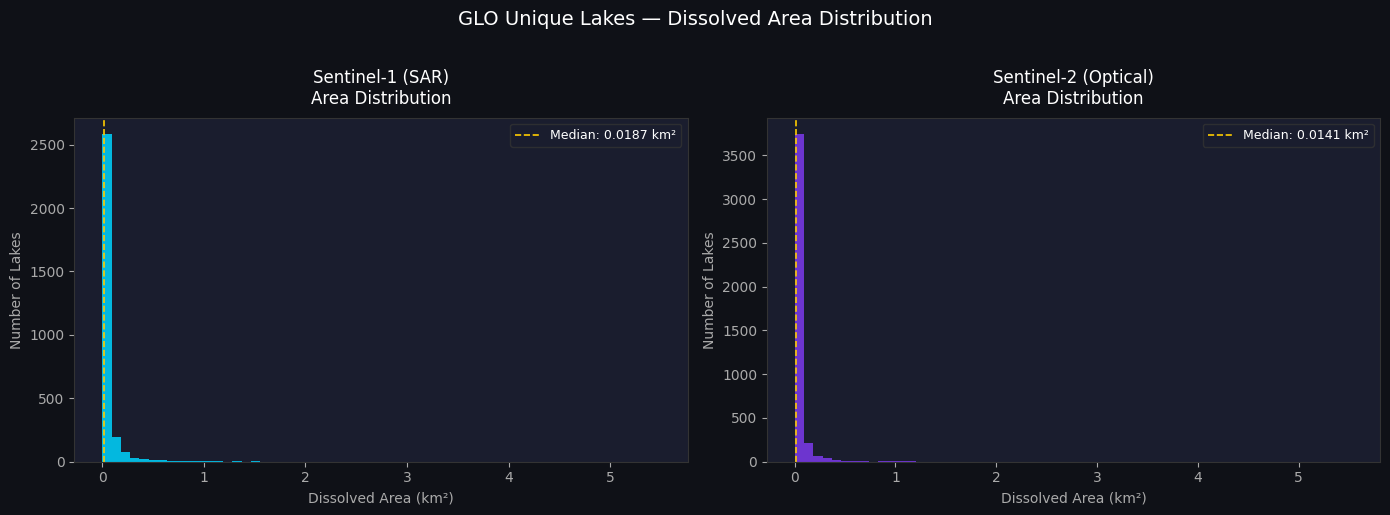

Saved to reports/figures/01_area_distribution.png


In [16]:
import os
os.makedirs('../reports/figures', exist_ok=True)

if 'AREA_DISSOLVED' in s1.columns and 'AREA_DISSOLVED' in s2.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('#0f1117')
    for ax, gdf, label, color in zip(
        axes,
        [s1, s2],
        ['Sentinel-1 (SAR)', 'Sentinel-2 (Optical)'],
        ['#00d4ff', '#7c3aed']
    ):
        ax.set_facecolor('#1a1d2e')
        ax.hist(gdf['AREA_DISSOLVED'].dropna(), bins=60, color=color, alpha=0.85, edgecolor='none')
        ax.set_title(f'{label}\nArea Distribution', color='white', fontsize=12, pad=10)
        ax.set_xlabel('Dissolved Area (km²)', color='#aaa', fontsize=10)
        ax.set_ylabel('Number of Lakes', color='#aaa', fontsize=10)
        ax.tick_params(colors='#aaa')
        for spine in ax.spines.values():
            spine.set_edgecolor('#333')
        median_val = gdf['AREA_DISSOLVED'].median()
        ax.axvline(median_val, color='#ffcc00', linestyle='--', linewidth=1.2,
                   label=f'Median: {median_val:.4f} km²')
        ax.legend(facecolor='#1a1d2e', edgecolor='#333', labelcolor='white', fontsize=9)
    plt.suptitle('GLO Unique Lakes — Dissolved Area Distribution', color='white', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('../reports/figures/01_area_distribution.png', dpi=150,
                bbox_inches='tight', facecolor='#0f1117')
    plt.show()
    print('Saved to reports/figures/01_area_distribution.png')

## 11 — Spatial Plot of Lake Polygons

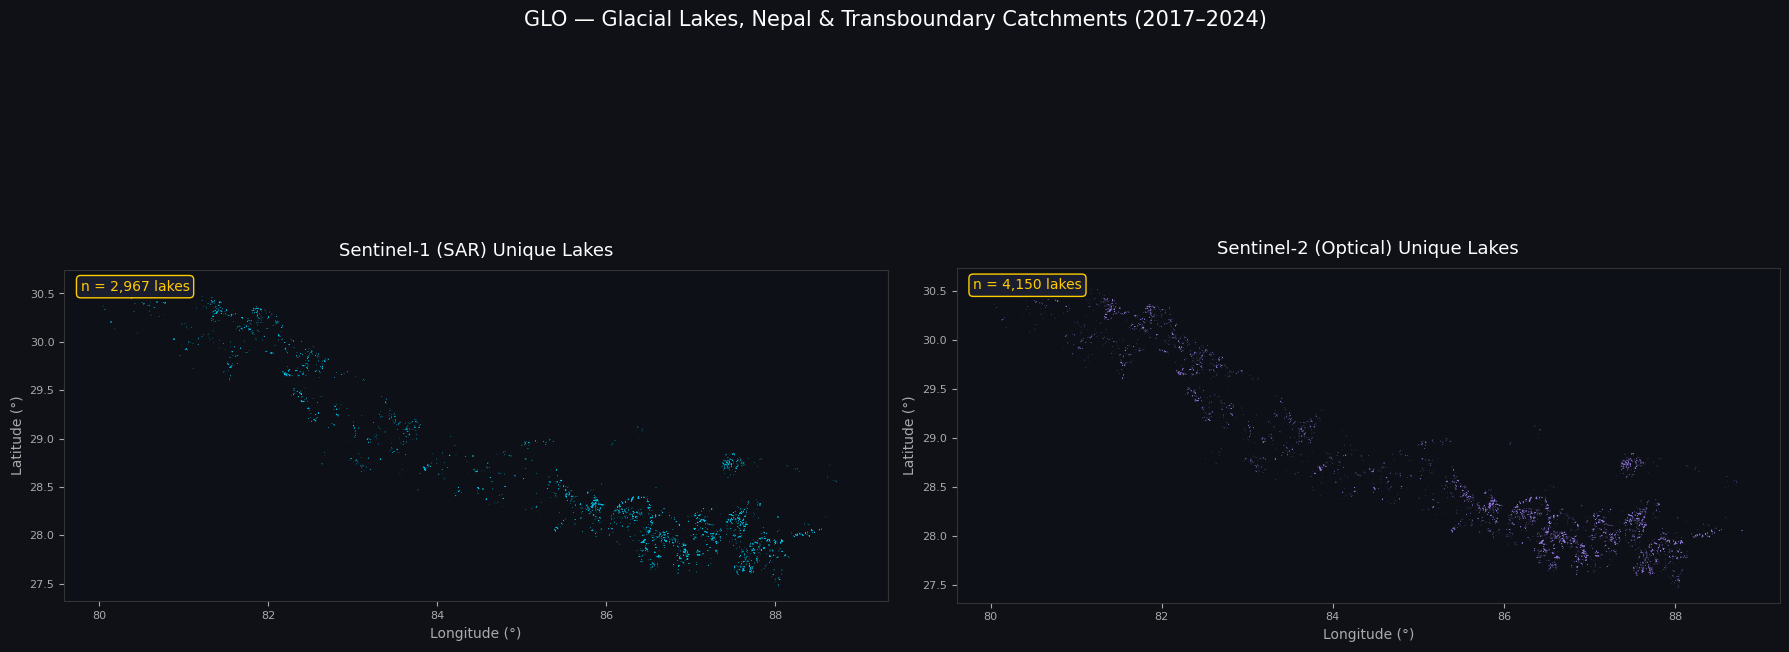

Saved to reports/figures/01_lake_polygons_map.png


In [17]:
s1_wgs = s1.to_crs(epsg=4326)
s2_wgs = s2.to_crs(epsg=4326)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#0f1117')

for ax, gdf, label, edge_color, face_color in zip(
    axes,
    [s1_wgs, s2_wgs],
    ['Sentinel-1 (SAR) Unique Lakes', 'Sentinel-2 (Optical) Unique Lakes'],
    ['#00d4ff', '#a78bfa'],
    ['#003a4d', '#2e1065']
):
    ax.set_facecolor('#0d1117')
    gdf.plot(ax=ax, edgecolor=edge_color, facecolor=face_color, linewidth=0.4, alpha=0.85)
    ax.set_title(label, color='white', fontsize=13, pad=10)
    ax.set_xlabel('Longitude (°)', color='#aaa', fontsize=10)
    ax.set_ylabel('Latitude (°)', color='#aaa', fontsize=10)
    ax.tick_params(colors='#aaa', labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333')
    ax.text(0.02, 0.97, f'n = {len(gdf):,} lakes', transform=ax.transAxes,
            color='#ffcc00', fontsize=10, va='top',
            bbox=dict(facecolor='#1a1d2e', edgecolor='#ffcc00', boxstyle='round,pad=0.3'))

plt.suptitle('GLO — Glacial Lakes, Nepal & Transboundary Catchments (2017–2024)',
             color='white', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/01_lake_polygons_map.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Saved to reports/figures/01_lake_polygons_map.png')

## 12 — Expansion Rate Analysis

In [18]:
for label, gdf in [('Sentinel-1', s1), ('Sentinel-2', s2)]:
    if 'EXPANSION_RATE' in gdf.columns and 'EXPANSION_RATE_SIG' in gdf.columns:
        sig      = gdf['EXPANSION_RATE_SIG'].value_counts()
        expanding = (gdf['EXPANSION_RATE'] > 0).sum()
        shrinking = (gdf['EXPANSION_RATE'] < 0).sum()
        stable    = (gdf['EXPANSION_RATE'] == 0).sum()
        print(f'=== {label} ===')
        print(f'  Expanding lakes (rate > 0)          : {expanding:,}')
        print(f'  Shrinking lakes (rate < 0)          : {shrinking:,}')
        print(f'  Stable   lakes (rate = 0)           : {stable:,}')
        print(f'  EXPANSION_RATE_SIG breakdown        : {sig.to_dict()}')
        print()

=== Sentinel-1 ===
  Expanding lakes (rate > 0)          : 981
  Shrinking lakes (rate < 0)          : 965
  Stable   lakes (rate = 0)           : 1,021
  EXPANSION_RATE_SIG breakdown        : {'FALSE': 1818, 'TRUE': 349}

=== Sentinel-2 ===
  Expanding lakes (rate > 0)          : 1,242
  Shrinking lakes (rate < 0)          : 803
  Stable   lakes (rate = 0)           : 2,099
  EXPANSION_RATE_SIG breakdown        : {'FALSE': 1911, 'TRUE': 367}



## 13 — Summary Table

In [19]:
summary_rows = []
for label, gdf, fname in [
    ('Sentinel-1', s1, 'S1_20172024_NTB_GLOID_UniqueLakesv1.02.gpkg'),
    ('Sentinel-2', s2, 'S2_20172024_NTB_GLOID_UniqueLakes_v1.02.gpkg')
]:
    gdf_wgs = gdf.to_crs(epsg=4326)
    b = gdf_wgs.total_bounds
    summary_rows.append({
        'File': fname,
        'Sensor': label,
        'Features': len(gdf),
        'CRS': str(gdf.crs.to_authority()),
        'Geometry': str(gdf.geometry.geom_type.unique().tolist()),
        'Lon range': f'{b[0]:.3f}° – {b[2]:.3f}°',
        'Lat range': f'{b[1]:.3f}° – {b[3]:.3f}°',
        'Unique GLO_IDs': gdf['GLO_ID'].nunique(),
        'Columns': len(gdf.columns),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Sensor')
display(summary_df)

,File,Features,CRS,Geometry,Lon range,Lat range,Unique GLO_IDs,Columns
Sensor,,,,,,,,
Sentinel-1,S1_20172024_NTB_GLOID_UniqueLakesv1.02.gpkg,2967,"('ESRI', '102025')",['MultiPolygon'],80.033° – 88.882°,27.474° – 30.590°,2967,18
Sentinel-2,S2_20172024_NTB_GLOID_UniqueLakes_v1.02.gpkg,4150,"('ESRI', '102025')",['MultiPolygon'],80.042° – 88.789°,27.474° – 30.582°,4150,18


## 14 — Key Findings

### What we have
- **Two GLO GeoPackage files** — Unique Lakes layers (dissolved max extents) from Sentinel-1 and Sentinel-2
- **Geometry**: **Polygon** (not points) — dissolved maximum lake extents, one polygon per unique lake
- **CRS**: `ESRI:102025` — Asia North Albers Equal Area Conic (projected, metres)
- **Unique lake ID**: `GLO_ID` (format: `GLO_<lon>_<lat>`) — encodes spatial identity
- **Geographic coverage**: Nepal and transboundary Himalayan catchments
- **Time period encoded**: 2017–2024 (as expansion rate statistics)
- **Key hazard-relevant fields**: `EXPANSION_RATE`, `EXPANSION_RATE_SIG`, `CONNECTIVITY`, `ELEVATION_*`

### What is NOT present (other GLO files not supplied)
- Annual lake time-series GeoPackages (S1 and S2 'All Lakes' files)
- Centroid layer (EPSG:4326 points)
- Deep learning model weights

### Recommended next steps for GlacierGuard AI
1. Use `GLO_ID` to cross-reference S1 and S2 datasets
2. Use `EXPANSION_RATE_SIG` + `EXPANSION_RATE` to rank highest-risk lakes
3. Reproject to `EPSG:4326` for web-mapping and API integration
4. Join with external hazard data using `LONGITUDE` / `LATITUDE`

---
## 15 — Thame GLOF Target Lake Identification

The **2025 Thame GLOF** (glacial lake outburst flood) originated from **Ngole Cho** (also known as Thame Cho), a proglacial lake in the Khumbu / Koshi basin of northeastern Nepal.

We query both GLO inventories using a broad bounding box centred on the event area (`86.50–86.70° E`, `27.75–27.90° N`) to identify candidate lakes and their GLO_IDs.

In [20]:
# ==========================================
# 15 — Thame GLOF Target Lake Identification
# ==========================================

# Approximate Thame/Ngole Cho event area.
# We deliberately use a broad spatial window first,
# then inspect the candidate GLO_IDs.

THAME_LON_MIN = 86.50
THAME_LON_MAX = 86.70
THAME_LAT_MIN = 27.75
THAME_LAT_MAX = 27.90

for label, gdf in [('Sentinel-1', s1), ('Sentinel-2', s2)]:

    candidates = gdf[
        (gdf['LONGITUDE'] >= THAME_LON_MIN) &
        (gdf['LONGITUDE'] <= THAME_LON_MAX) &
        (gdf['LATITUDE']  >= THAME_LAT_MIN) &
        (gdf['LATITUDE']  <= THAME_LAT_MAX)
    ].copy()

    print('=' * 70)
    print(f'{label} — THAME REGION CANDIDATES')
    print('=' * 70)

    cols = [
        'GLO_ID',
        'COUNTRY',
        'BASIN',
        'CONNECTIVITY',
        'LONGITUDE',
        'LATITUDE',
        'ELEVATION_MEAN',
        'AREA_DISSOLVED',
        'EXPANSION_RATE',
        'EXPANSION_RATE_SIG'
    ]
    cols = [c for c in cols if c in candidates.columns]

    display(
        candidates[cols]
        .sort_values(['LATITUDE', 'LONGITUDE'])
        .reset_index(drop=True)
    )

    print(f'Candidate lakes: {len(candidates)}')
    print()

Sentinel-1 — THAME REGION CANDIDATES


,GLO_ID,COUNTRY,BASIN,CONNECTIVITY,LONGITUDE,LATITUDE,ELEVATION_MEAN,AREA_DISSOLVED,EXPANSION_RATE,EXPANSION_RATE_SIG
0,GLO_86.52419_27.75048,Nepal,Koshi,Glacier-fed,86.52452,27.75089,4108.324707,0.072328,0.0005,FALSE
1,GLO_86.62558_27.76795,Nepal,Koshi,Glacier-fed,86.62556,27.76814,4824.793457,0.011096,0.0001,FALSE
2,GLO_86.64285_27.77766,Nepal,Koshi,Glacier-fed,86.64282,27.77766,5169.886230,0.305704,-0.0011,FALSE
3,GLO_86.59886_27.77762,Nepal,Koshi,Glacier-fed,86.59472,27.77901,4846.791992,1.390046,0.0113,FALSE
4,GLO_86.628_27.78287,Nepal,Koshi,Glacier-fed,86.62817,27.78296,4982.683594,0.016556,-0.0005,FALSE
5,GLO_86.632_27.78593,Nepal,Koshi,Glacier-fed,86.63186,27.78583,5090.243164,0.010047,0.0000,None
6,GLO_86.63265_27.78863,Nepal,Koshi,Glacier-fed,86.63222,27.78835,5186.975098,0.003349,0.0000,None
7,GLO_86.61366_27.78922,Nepal,Koshi,Glacier-fed,86.61358,27.78929,5172.184082,0.001763,0.0000,None
8,GLO_86.62025_27.79158,Nepal,Koshi,Glacier-fed,86.62088,27.79079,5152.648926,0.485024,0.0011,FALSE
9,GLO_86.61742_27.79541,Nepal,Koshi,Glacier-fed,86.61754,27.79527,5179.450684,0.018990,0.0001,FALSE


Candidate lakes: 23

Sentinel-2 — THAME REGION CANDIDATES


,GLO_ID,COUNTRY,BASIN,CONNECTIVITY,LONGITUDE,LATITUDE,ELEVATION_MEAN,AREA_DISSOLVED,EXPANSION_RATE,EXPANSION_RATE_SIG
0,GLO_86.52419_27.75048,Nepal,Koshi,Glacier-fed,86.52419,27.75048,4107.539062,0.049004,-0.0006,FALSE
1,GLO_86.52591_27.75407,Nepal,Koshi,Glacier-fed,86.52591,27.75407,4113.589355,0.004056,0.0000,None
2,GLO_86.62558_27.76795,Nepal,Koshi,Glacier-fed,86.62558,27.76795,4824.215332,0.007119,0.0000,None
3,GLO_86.6451_27.77151,Nepal,Koshi,Non Glacier-fed,86.64510,27.77151,5180.803223,0.022598,0.0002,FALSE
4,GLO_86.6815_27.77743,Nepal,Koshi,Non Glacier-fed,86.68150,27.77743,4522.492676,0.001738,0.0000,None
5,GLO_86.59886_27.77762,Nepal,Koshi,Glacier-fed,86.59886,27.77762,4855.861328,1.596591,0.0370,TRUE
6,GLO_86.64285_27.77766,Nepal,Koshi,Glacier-fed,86.64285,27.77766,5169.367676,0.309584,-0.0001,FALSE
7,GLO_86.58984_27.78124,Nepal,Koshi,Glacier-fed,86.58984,27.78124,5057.653320,0.009602,0.0002,TRUE
8,GLO_86.628_27.78287,Nepal,Koshi,Glacier-fed,86.62800,27.78287,4982.760254,0.028392,0.0000,FALSE
9,GLO_86.632_27.78593,Nepal,Koshi,Glacier-fed,86.63200,27.78593,5090.304688,0.027233,0.0001,TRUE


Candidate lakes: 39



In [23]:
# ==========================================
# 16 — Thame GLOF Event Lake Matching
# ==========================================

# Known Thame GLOF lake reference coordinates
# derived from the event inventory identifiers.

thame_event_coords = pd.DataFrame({
    'event_id': [
        'GL086573E27827N',
        'GL086569E27826N',
        'GL086570E27823N'
    ],
    'event_lon': [
        86.573,
        86.569,
        86.570
    ],
    'event_lat': [
        27.827,
        27.826,
        27.823
    ]
})


def match_nearest_lakes(gdf, event_coords, max_distance=0.002):
    """Match each event coordinate to the nearest GLO lake within max_distance degrees.

    Parameters
    ----------
    gdf : GeoDataFrame
        GLO inventory (must have LONGITUDE, LATITUDE columns).
    event_coords : DataFrame
        Rows with columns: event_id, event_lon, event_lat.
    max_distance : float
        Maximum allowed Euclidean distance in decimal degrees.
        Matches exceeding this threshold are returned as NO_MATCH.
        Default 0.002 deg ≈ 200 m at these latitudes.

    Returns
    -------
    pd.DataFrame with one row per event, including match_status.
    """
    results = []

    for _, event in event_coords.iterrows():

        distances = (
            (gdf['LONGITUDE'] - event['event_lon'])**2 +
            (gdf['LATITUDE']  - event['event_lat'])**2
        ) ** 0.5

        idx = distances.idxmin()
        nearest_distance = distances.loc[idx]

        # Reject match if outside allowed coordinate tolerance
        if nearest_distance > max_distance:
            results.append({
                'event_id':     event['event_id'],
                'GLO_ID':       None,
                'distance_deg': nearest_distance,
                'match_status': 'NO_MATCH'
            })
            continue

        row = gdf.loc[idx]

        results.append({
            'event_id':          event['event_id'],
            'GLO_ID':            row['GLO_ID'],
            'longitude':         row['LONGITUDE'],
            'latitude':          row['LATITUDE'],
            'distance_deg':      nearest_distance,
            'CONNECTIVITY':      row['CONNECTIVITY'],
            'BASIN':             row['BASIN'],
            'ELEVATION_MEAN':    row['ELEVATION_MEAN'],
            'AREA_DISSOLVED':    row['AREA_DISSOLVED'],
            'EXPANSION_RATE':    row['EXPANSION_RATE'],
            'EXPANSION_RATE_SIG': row['EXPANSION_RATE_SIG'],
            'match_status':      'MATCH'
        })

    return pd.DataFrame(results)


print('=== Sentinel-1 Thame Event Lake Matches ===')
thame_s1 = match_nearest_lakes(s1, thame_event_coords)
display(thame_s1)

print('=== Sentinel-2 Thame Event Lake Matches ===')
thame_s2 = match_nearest_lakes(s2, thame_event_coords)
display(thame_s2)

# Summarise match quality
for label, df in [('S1', thame_s1), ('S2', thame_s2)]:
    matched   = (df['match_status'] == 'MATCH').sum()
    unmatched = (df['match_status'] == 'NO_MATCH').sum()
    print(f'{label}: {matched} matched, {unmatched} NO_MATCH (threshold = 0.002° ≈ 200 m)')

In [39]:
# ============================================================
# 17 — Annual GLO Time-Series Files
# ============================================================

S1_ANNUAL_PATH = GLO_DIR / 'S1_20172024_NTB_GLOID_v1.02.gpkg'

S2_ANNUAL_PATH = GLO_DIR / 'S2_20172024_NTB_GLOID_v1.02.gpkg'

print("S1 annual exists:", S1_ANNUAL_PATH.exists())
print("S2 annual exists:", S2_ANNUAL_PATH.exists())

if S1_ANNUAL_PATH.exists():
    print(f"S1 annual size: {S1_ANNUAL_PATH.stat().st_size / 1e6:.2f} MB")

if S2_ANNUAL_PATH.exists():
    print(f"S2 annual size: {S2_ANNUAL_PATH.stat().st_size / 1e6:.2f} MB")

S1 annual exists: True
S2 annual exists: True
S1 annual size: 29.98 MB
S2 annual size: 36.32 MB


---
## 17 — Annual Time-Series: Files Needed & Availability

The three matched GLO_IDs represent **dissolved unique-lake polygons** — the merged
maximum extents across 2017–2024. That means `EXPANSION_RATE` is pre-computed summary
statistic, not raw annual observations.

To build a genuine temporal feature set (baseline → growth → acceleration → pre-event
anomaly) we need the **annual polygon layers**:

| File needed | Status |
|---|---|
| `S1_20172024_NTB_GLOID_v1.02.gpkg` | ❌ Not in `raw/GLO/` |
| `S2_20172024_NTB_GLOID_v1.02.gpkg` | ❌ Not in `raw/GLO/` |

The cell below checks the raw data directory programmatically, confirms what is missing,
and records the Zenodo DOI and exact filenames needed for the next acquisition step.

In [34]:
import geopandas as gpd

# ============================================================
# UNIQUE LAKES SCHEMA INSPECTION
# ============================================================

print("=" * 70)
print("S1 UNIQUE LAKES SCHEMA")
print("=" * 70)

s1_unique = gpd.read_file(S1_UNIQUE_PATH)

print("Shape:", s1_unique.shape)
print("\nColumns:")
print(s1_unique.columns.tolist())

print("\nGeometry type:")
print(s1_unique.geometry.geom_type.value_counts())

print("\nCRS:")
print(s1_unique.crs)

print("\nFirst 5 rows:")
display(s1_unique.head())


print("\n" + "=" * 70)
print("S2 UNIQUE LAKES SCHEMA")
print("=" * 70)

s2_unique = gpd.read_file(S2_UNIQUE_PATH)

print("Shape:", s2_unique.shape)
print("\nColumns:")
print(s2_unique.columns.tolist())

print("\nGeometry type:")
print(s2_unique.geometry.geom_type.value_counts())

print("\nCRS:")
print(s2_unique.crs)

print("\nFirst 5 rows:")
display(s2_unique.head())

S1 UNIQUE LAKES SCHEMA
Shape: (2967, 18)

Columns:
['GLO_ID', 'COUNTRY', 'BASIN', 'CONNECTIVITY', 'DATA_SOURCE', 'EXPANSION_RATE', 'EXPANSION_UNCERTAINTY', 'EXPANSION_RATE_SIG', 'S2_MSTAT', 'LONGITUDE', 'LATITUDE', 'GTNG_REGION_O2', 'ELEVATION_MIN', 'ELEVATION_MEDIAN', 'ELEVATION_MEAN', 'AREA_DISSOLVED', 'PERIMETER_DISSOLVED', 'geometry']

Geometry type:
MultiPolygon    2967
Name: count, dtype: int64

CRS:
PROJCS["Asia_North_Albers_Equal_Area_Conic",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",30],PARAMETER["longitude_of_center",95],PARAMETER["standard_parallel_1",15],PARAMETER["standard_parallel_2",65],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Ea

,GLO_ID,COUNTRY,BASIN,CONNECTIVITY,DATA_SOURCE,EXPANSION_RATE,EXPANSION_UNCERTAINTY,EXPANSION_RATE_SIG,S2_MSTAT,LONGITUDE,LATITUDE,GTNG_REGION_O2,ELEVATION_MIN,ELEVATION_MEDIAN,ELEVATION_MEAN,AREA_DISSOLVED,PERIMETER_DISSOLVED,geometry
0,GLO_80.03311_30.32452,India,Karnali,Glacier-fed,Sentinel-1,0.0000,0.0000,None,0.0,80.03311,30.32452,15-01,4887.0,4888.483007,4888.430176,0.008259,0.429067,"MULTIPOLYGON (((-1335760.275 140584.498, -1335..."
1,GLO_80.04206_30.3709,India,Karnali,Glacier-fed,Sentinel-1,0.0000,0.0000,None,1.0,80.04200,30.37087,15-01,4589.0,4608.617580,4607.427734,0.008255,0.471461,"MULTIPOLYGON (((-1334150.506 145928.986, -1334..."
2,GLO_80.05413_30.37819,India,Karnali,Glacier-fed,Sentinel-1,0.0000,0.0000,None,0.0,80.05413,30.37819,15-01,4504.0,4509.000000,4513.311523,0.001290,0.166014,"MULTIPOLYGON (((-1332946.123 146566.319, -1332..."
3,GLO_80.05556_30.37113,India,Karnali,Glacier-fed,Sentinel-1,0.0000,0.0000,None,0.0,80.05556,30.37113,15-01,4476.0,4476.500000,4476.208984,0.008269,0.547027,"MULTIPOLYGON (((-1332943.646 145733.104, -1332..."
4,GLO_80.07262_30.33587,India,Karnali,Glacier-fed,Sentinel-1,0.0041,0.0057,FALSE,1.0,80.07299,30.33669,15-01,4191.0,4201.754220,4206.367676,0.080575,1.709878,"MULTIPOLYGON (((-1332068.136 141619.017, -1332..."



S2 UNIQUE LAKES SCHEMA
Shape: (4150, 18)

Columns:
['GLO_ID', 'COUNTRY', 'BASIN', 'CONNECTIVITY', 'ELEVATION_MEAN', 'ELEVATION_MIN', 'ELEVATION_MEDIAN', 'DATA_SOURCE', 'REF_MSTAT', 'LONGITUDE', 'LATITUDE', 'GTNG_REGION_O2', 'EXPANSION_RATE', 'EXPANSION_UNCERTAINTY', 'EXPANSION_RATE_SIG', 'AREA_DISSOLVED', 'PERIMETER_DISSOLVED', 'geometry']

Geometry type:
MultiPolygon    4150
Name: count, dtype: int64

CRS:
PROJCS["Asia_North_Albers_Equal_Area_Conic",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",30],PARAMETER["longitude_of_center",95],PARAMETER["standard_parallel_1",15],PARAMETER["standard_parallel_2",65],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["

,GLO_ID,COUNTRY,BASIN,CONNECTIVITY,ELEVATION_MEAN,ELEVATION_MIN,ELEVATION_MEDIAN,DATA_SOURCE,REF_MSTAT,LONGITUDE,LATITUDE,GTNG_REGION_O2,EXPANSION_RATE,EXPANSION_UNCERTAINTY,EXPANSION_RATE_SIG,AREA_DISSOLVED,PERIMETER_DISSOLVED,geometry
0,GLO_80.04206_30.3709,India,Karnali,Glacier-fed,4606.184082,4589.0,4606.044971,Sentinel-2,dl_new,80.04206,30.37090,15-01,0.0000,0.0000,None,0.008146,0.485041,"MULTIPOLYGON (((-1334168.469 145789.718, -1334..."
1,GLO_80.05083_30.54339,India,Karnali,Non Glacier-fed,4618.577148,4610.0,4617.768531,Sentinel-2,dl_new,80.05083,30.54339,15-01,0.0000,0.0000,None,0.002660,0.295060,"MULTIPOLYGON (((-1330293.604 166002.836, -1330..."
2,GLO_80.07074_30.5746,India,Karnali,Glacier-fed,5059.776367,5049.0,5057.523129,Sentinel-2,dl_new,80.07074,30.57460,15-01,0.0000,0.0000,None,0.002577,0.292571,"MULTIPOLYGON (((-1327959.568 169403.599, -1327..."
3,GLO_80.07262_30.33587,India,Karnali,Glacier-fed,4219.072266,4203.0,4219.111548,Sentinel-2,NA,80.07262,30.33587,15-01,0.0038,0.0014,TRUE,0.033167,0.950797,"MULTIPOLYGON (((-1332035.014 141431.635, -1332..."
4,GLO_80.07563_30.51573,India,Karnali,Glacier-fed,4128.408203,4127.0,4128.390832,Sentinel-2,dl_new,80.07563,30.51573,15-01,0.0000,0.0000,None,0.004738,0.360732,"MULTIPOLYGON (((-1328570.429 162474.429, -1328..."


In [ ]:
import geopandas as gpd

print("=== S1 UNIQUE LAKES SCHEMA ===")
s1_unique = gpd.read_file(S1_ANNUAL_PATH)

print("Shape:", s1_unique.shape)
print("Columns:")
print(s1_unique.columns.tolist())
print("\nFirst 5 rows:")
display(s1_unique.head())


print("\n=== S2 UNIQUE LAKES SCHEMA ===")
s2_unique = gpd.read_file(S2_ANNUAL_PATH)

print("Shape:", s2_unique.shape)
print("Columns:")
print(s2_unique.columns.tolist())
print("\nFirst 5 rows:")
display(s2_unique.head())

=== S1 UNIQUE LAKES SCHEMA ===
Shape: (2967, 18)
Columns:
['GLO_ID', 'COUNTRY', 'BASIN', 'CONNECTIVITY', 'DATA_SOURCE', 'EXPANSION_RATE', 'EXPANSION_UNCERTAINTY', 'EXPANSION_RATE_SIG', 'S2_MSTAT', 'LONGITUDE', 'LATITUDE', 'GTNG_REGION_O2', 'ELEVATION_MIN', 'ELEVATION_MEDIAN', 'ELEVATION_MEAN', 'AREA_DISSOLVED', 'PERIMETER_DISSOLVED', 'geometry']

First 5 rows:


,GLO_ID,COUNTRY,BASIN,CONNECTIVITY,DATA_SOURCE,EXPANSION_RATE,EXPANSION_UNCERTAINTY,EXPANSION_RATE_SIG,S2_MSTAT,LONGITUDE,LATITUDE,GTNG_REGION_O2,ELEVATION_MIN,ELEVATION_MEDIAN,ELEVATION_MEAN,AREA_DISSOLVED,PERIMETER_DISSOLVED,geometry
0,GLO_80.03311_30.32452,India,Karnali,Glacier-fed,Sentinel-1,0.0000,0.0000,None,0.0,80.03311,30.32452,15-01,4887.0,4888.483007,4888.430176,0.008259,0.429067,"MULTIPOLYGON (((-1335760.275 140584.498, -1335..."
1,GLO_80.04206_30.3709,India,Karnali,Glacier-fed,Sentinel-1,0.0000,0.0000,None,1.0,80.04200,30.37087,15-01,4589.0,4608.617580,4607.427734,0.008255,0.471461,"MULTIPOLYGON (((-1334150.506 145928.986, -1334..."
2,GLO_80.05413_30.37819,India,Karnali,Glacier-fed,Sentinel-1,0.0000,0.0000,None,0.0,80.05413,30.37819,15-01,4504.0,4509.000000,4513.311523,0.001290,0.166014,"MULTIPOLYGON (((-1332946.123 146566.319, -1332..."
3,GLO_80.05556_30.37113,India,Karnali,Glacier-fed,Sentinel-1,0.0000,0.0000,None,0.0,80.05556,30.37113,15-01,4476.0,4476.500000,4476.208984,0.008269,0.547027,"MULTIPOLYGON (((-1332943.646 145733.104, -1332..."
4,GLO_80.07262_30.33587,India,Karnali,Glacier-fed,Sentinel-1,0.0041,0.0057,FALSE,1.0,80.07299,30.33669,15-01,4191.0,4201.754220,4206.367676,0.080575,1.709878,"MULTIPOLYGON (((-1332068.136 141619.017, -1332..."



=== S2 UNIQUE LAKES SCHEMA ===
Shape: (4150, 18)
Columns:
['GLO_ID', 'COUNTRY', 'BASIN', 'CONNECTIVITY', 'ELEVATION_MEAN', 'ELEVATION_MIN', 'ELEVATION_MEDIAN', 'DATA_SOURCE', 'REF_MSTAT', 'LONGITUDE', 'LATITUDE', 'GTNG_REGION_O2', 'EXPANSION_RATE', 'EXPANSION_UNCERTAINTY', 'EXPANSION_RATE_SIG', 'AREA_DISSOLVED', 'PERIMETER_DISSOLVED', 'geometry']

First 5 rows:


,GLO_ID,COUNTRY,BASIN,CONNECTIVITY,ELEVATION_MEAN,ELEVATION_MIN,ELEVATION_MEDIAN,DATA_SOURCE,REF_MSTAT,LONGITUDE,LATITUDE,GTNG_REGION_O2,EXPANSION_RATE,EXPANSION_UNCERTAINTY,EXPANSION_RATE_SIG,AREA_DISSOLVED,PERIMETER_DISSOLVED,geometry
0,GLO_80.04206_30.3709,India,Karnali,Glacier-fed,4606.184082,4589.0,4606.044971,Sentinel-2,dl_new,80.04206,30.37090,15-01,0.0000,0.0000,None,0.008146,0.485041,"MULTIPOLYGON (((-1334168.469 145789.718, -1334..."
1,GLO_80.05083_30.54339,India,Karnali,Non Glacier-fed,4618.577148,4610.0,4617.768531,Sentinel-2,dl_new,80.05083,30.54339,15-01,0.0000,0.0000,None,0.002660,0.295060,"MULTIPOLYGON (((-1330293.604 166002.836, -1330..."
2,GLO_80.07074_30.5746,India,Karnali,Glacier-fed,5059.776367,5049.0,5057.523129,Sentinel-2,dl_new,80.07074,30.57460,15-01,0.0000,0.0000,None,0.002577,0.292571,"MULTIPOLYGON (((-1327959.568 169403.599, -1327..."
3,GLO_80.07262_30.33587,India,Karnali,Glacier-fed,4219.072266,4203.0,4219.111548,Sentinel-2,NA,80.07262,30.33587,15-01,0.0038,0.0014,TRUE,0.033167,0.950797,"MULTIPOLYGON (((-1332035.014 141431.635, -1332..."
4,GLO_80.07563_30.51573,India,Karnali,Glacier-fed,4128.408203,4127.0,4128.390832,Sentinel-2,dl_new,80.07563,30.51573,15-01,0.0000,0.0000,None,0.004738,0.360732,"MULTIPOLYGON (((-1328570.429 162474.429, -1328..."


In [35]:
# ============================================================
# 17B — ANNUAL GLO FILE SCHEMA INSPECTION
# ============================================================

import geopandas as gpd

print("=" * 70)
print("S1 ANNUAL GLO — SCHEMA")
print("=" * 70)

s1_annual = gpd.read_file(S1_ANNUAL_PATH)

print("Shape:", s1_annual.shape)
print("\nColumns:")
print(s1_annual.columns.tolist())

print("\nData types:")
print(s1_annual.dtypes)

print("\nFirst 5 rows:")
display(s1_annual.head())

print("\n" + "=" * 70)
print("S2 ANNUAL GLO — SCHEMA")
print("=" * 70)

s2_annual = gpd.read_file(S2_ANNUAL_PATH)

print("Shape:", s2_annual.shape)
print("\nColumns:")
print(s2_annual.columns.tolist())

print("\nData types:")
print(s2_annual.dtypes)

print("\nFirst 5 rows:")
display(s2_annual.head())

S1 ANNUAL GLO — SCHEMA
Shape: (2967, 18)

Columns:
['GLO_ID', 'COUNTRY', 'BASIN', 'CONNECTIVITY', 'DATA_SOURCE', 'EXPANSION_RATE', 'EXPANSION_UNCERTAINTY', 'EXPANSION_RATE_SIG', 'S2_MSTAT', 'LONGITUDE', 'LATITUDE', 'GTNG_REGION_O2', 'ELEVATION_MIN', 'ELEVATION_MEDIAN', 'ELEVATION_MEAN', 'AREA_DISSOLVED', 'PERIMETER_DISSOLVED', 'geometry']

Data types:
GLO_ID                     object
COUNTRY                    object
BASIN                      object
CONNECTIVITY               object
DATA_SOURCE                object
EXPANSION_RATE            float64
EXPANSION_UNCERTAINTY     float64
EXPANSION_RATE_SIG         object
S2_MSTAT                  float64
LONGITUDE                 float64
LATITUDE                  float64
GTNG_REGION_O2             object
ELEVATION_MIN             float64
ELEVATION_MEDIAN          float64
ELEVATION_MEAN            float64
AREA_DISSOLVED            float64
PERIMETER_DISSOLVED       float64
geometry                 geometry
dtype: object

First 5 rows:


,GLO_ID,COUNTRY,BASIN,CONNECTIVITY,DATA_SOURCE,EXPANSION_RATE,EXPANSION_UNCERTAINTY,EXPANSION_RATE_SIG,S2_MSTAT,LONGITUDE,LATITUDE,GTNG_REGION_O2,ELEVATION_MIN,ELEVATION_MEDIAN,ELEVATION_MEAN,AREA_DISSOLVED,PERIMETER_DISSOLVED,geometry
0,GLO_80.03311_30.32452,India,Karnali,Glacier-fed,Sentinel-1,0.0000,0.0000,None,0.0,80.03311,30.32452,15-01,4887.0,4888.483007,4888.430176,0.008259,0.429067,"MULTIPOLYGON (((-1335760.275 140584.498, -1335..."
1,GLO_80.04206_30.3709,India,Karnali,Glacier-fed,Sentinel-1,0.0000,0.0000,None,1.0,80.04200,30.37087,15-01,4589.0,4608.617580,4607.427734,0.008255,0.471461,"MULTIPOLYGON (((-1334150.506 145928.986, -1334..."
2,GLO_80.05413_30.37819,India,Karnali,Glacier-fed,Sentinel-1,0.0000,0.0000,None,0.0,80.05413,30.37819,15-01,4504.0,4509.000000,4513.311523,0.001290,0.166014,"MULTIPOLYGON (((-1332946.123 146566.319, -1332..."
3,GLO_80.05556_30.37113,India,Karnali,Glacier-fed,Sentinel-1,0.0000,0.0000,None,0.0,80.05556,30.37113,15-01,4476.0,4476.500000,4476.208984,0.008269,0.547027,"MULTIPOLYGON (((-1332943.646 145733.104, -1332..."
4,GLO_80.07262_30.33587,India,Karnali,Glacier-fed,Sentinel-1,0.0041,0.0057,FALSE,1.0,80.07299,30.33669,15-01,4191.0,4201.754220,4206.367676,0.080575,1.709878,"MULTIPOLYGON (((-1332068.136 141619.017, -1332..."



S2 ANNUAL GLO — SCHEMA
Shape: (4150, 18)

Columns:
['GLO_ID', 'COUNTRY', 'BASIN', 'CONNECTIVITY', 'ELEVATION_MEAN', 'ELEVATION_MIN', 'ELEVATION_MEDIAN', 'DATA_SOURCE', 'REF_MSTAT', 'LONGITUDE', 'LATITUDE', 'GTNG_REGION_O2', 'EXPANSION_RATE', 'EXPANSION_UNCERTAINTY', 'EXPANSION_RATE_SIG', 'AREA_DISSOLVED', 'PERIMETER_DISSOLVED', 'geometry']

Data types:
GLO_ID                     object
COUNTRY                    object
BASIN                      object
CONNECTIVITY               object
ELEVATION_MEAN            float64
ELEVATION_MIN             float64
ELEVATION_MEDIAN          float64
DATA_SOURCE                object
REF_MSTAT                  object
LONGITUDE                 float64
LATITUDE                  float64
GTNG_REGION_O2             object
EXPANSION_RATE            float64
EXPANSION_UNCERTAINTY     float64
EXPANSION_RATE_SIG         object
AREA_DISSOLVED            float64
PERIMETER_DISSOLVED       float64
geometry                 geometry
dtype: object

First 5 rows:


,GLO_ID,COUNTRY,BASIN,CONNECTIVITY,ELEVATION_MEAN,ELEVATION_MIN,ELEVATION_MEDIAN,DATA_SOURCE,REF_MSTAT,LONGITUDE,LATITUDE,GTNG_REGION_O2,EXPANSION_RATE,EXPANSION_UNCERTAINTY,EXPANSION_RATE_SIG,AREA_DISSOLVED,PERIMETER_DISSOLVED,geometry
0,GLO_80.04206_30.3709,India,Karnali,Glacier-fed,4606.184082,4589.0,4606.044971,Sentinel-2,dl_new,80.04206,30.37090,15-01,0.0000,0.0000,None,0.008146,0.485041,"MULTIPOLYGON (((-1334168.469 145789.718, -1334..."
1,GLO_80.05083_30.54339,India,Karnali,Non Glacier-fed,4618.577148,4610.0,4617.768531,Sentinel-2,dl_new,80.05083,30.54339,15-01,0.0000,0.0000,None,0.002660,0.295060,"MULTIPOLYGON (((-1330293.604 166002.836, -1330..."
2,GLO_80.07074_30.5746,India,Karnali,Glacier-fed,5059.776367,5049.0,5057.523129,Sentinel-2,dl_new,80.07074,30.57460,15-01,0.0000,0.0000,None,0.002577,0.292571,"MULTIPOLYGON (((-1327959.568 169403.599, -1327..."
3,GLO_80.07262_30.33587,India,Karnali,Glacier-fed,4219.072266,4203.0,4219.111548,Sentinel-2,NA,80.07262,30.33587,15-01,0.0038,0.0014,TRUE,0.033167,0.950797,"MULTIPOLYGON (((-1332035.014 141431.635, -1332..."
4,GLO_80.07563_30.51573,India,Karnali,Glacier-fed,4128.408203,4127.0,4128.390832,Sentinel-2,dl_new,80.07563,30.51573,15-01,0.0000,0.0000,None,0.004738,0.360732,"MULTIPOLYGON (((-1328570.429 162474.429, -1328..."


In [36]:
print("=" * 70)
print("S1 ANNUAL — TEMPORAL STRUCTURE CHECK")
print("=" * 70)

print("Number of rows:", len(s1_annual))
print("Number of unique GLO_IDs:", s1_annual["GLO_ID"].nunique())

print("\nRows per GLO_ID:")
print(s1_annual["GLO_ID"].value_counts().describe())

print("\nPotential temporal columns:")
temporal_cols = [
    c for c in s1_annual.columns
    if any(x in c.lower() for x in ["year", "date", "time", "period", "season", "obs"])
]

print(temporal_cols)

print("\nAll S1 columns:")
for i, col in enumerate(s1_annual.columns, 1):
    print(f"{i:02d}. {col}")

S1 ANNUAL — TEMPORAL STRUCTURE CHECK
Number of rows: 2967
Number of unique GLO_IDs: 2967

Rows per GLO_ID:
count    2967.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: count, dtype: float64

Potential temporal columns:
[]

All S1 columns:
01. GLO_ID
02. COUNTRY
03. BASIN
04. CONNECTIVITY
05. DATA_SOURCE
06. EXPANSION_RATE
07. EXPANSION_UNCERTAINTY
08. EXPANSION_RATE_SIG
09. S2_MSTAT
10. LONGITUDE
11. LATITUDE
12. GTNG_REGION_O2
13. ELEVATION_MIN
14. ELEVATION_MEDIAN
15. ELEVATION_MEAN
16. AREA_DISSOLVED
17. PERIMETER_DISSOLVED
18. geometry


In [37]:
print("=" * 70)
print("S2 ANNUAL — TEMPORAL STRUCTURE CHECK")
print("=" * 70)

print("Number of rows:", len(s2_annual))
print("Number of unique GLO_IDs:", s2_annual["GLO_ID"].nunique())

print("\nRows per GLO_ID:")
print(s2_annual["GLO_ID"].value_counts().describe())

print("\nPotential temporal columns:")
temporal_cols = [
    c for c in s2_annual.columns
    if any(x in c.lower() for x in ["year", "date", "time", "period", "season", "obs"])
]

print(temporal_cols)

print("\nAll S2 columns:")
for i, col in enumerate(s2_annual.columns, 1):
    print(f"{i:02d}. {col}")

S2 ANNUAL — TEMPORAL STRUCTURE CHECK
Number of rows: 4150
Number of unique GLO_IDs: 4150

Rows per GLO_ID:
count    4150.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: count, dtype: float64

Potential temporal columns:
[]

All S2 columns:
01. GLO_ID
02. COUNTRY
03. BASIN
04. CONNECTIVITY
05. ELEVATION_MEAN
06. ELEVATION_MIN
07. ELEVATION_MEDIAN
08. DATA_SOURCE
09. REF_MSTAT
10. LONGITUDE
11. LATITUDE
12. GTNG_REGION_O2
13. EXPANSION_RATE
14. EXPANSION_UNCERTAINTY
15. EXPANSION_RATE_SIG
16. AREA_DISSOLVED
17. PERIMETER_DISSOLVED
18. geometry


In [33]:
# ============================================================
# TEMPORAL / AREA FIELD INSPECTION
# ============================================================

print("=" * 70)
print("S1 POTENTIAL TEMPORAL / AREA FIELDS")
print("=" * 70)

for col in s1_unique.columns:
    print(f"{col:35} | dtype={s1_unique[col].dtype}")

print("\n" + "=" * 70)
print("S2 POTENTIAL TEMPORAL / AREA FIELDS")
print("=" * 70)

for col in s2_unique.columns:
    print(f"{col:35} | dtype={s2_unique[col].dtype}")

S1 POTENTIAL TEMPORAL / AREA FIELDS
GLO_ID                              | dtype=object
COUNTRY                             | dtype=object
BASIN                               | dtype=object
CONNECTIVITY                        | dtype=object
DATA_SOURCE                         | dtype=object
EXPANSION_RATE                      | dtype=float64
EXPANSION_UNCERTAINTY               | dtype=float64
EXPANSION_RATE_SIG                  | dtype=object
S2_MSTAT                            | dtype=float64
LONGITUDE                           | dtype=float64
LATITUDE                            | dtype=float64
GTNG_REGION_O2                      | dtype=object
ELEVATION_MIN                       | dtype=float64
ELEVATION_MEDIAN                    | dtype=float64
ELEVATION_MEAN                      | dtype=float64
AREA_DISSOLVED                      | dtype=float64
PERIMETER_DISSOLVED                 | dtype=float64
geometry                            | dtype=geometry

S2 POTENTIAL TEMPORAL / AREA FIEL

In [40]:
import geopandas as gpd

s1_annual = gpd.read_file(S1_ANNUAL_PATH)
s2_annual = gpd.read_file(S2_ANNUAL_PATH)

print("S1 annual shape:", s1_annual.shape)
print("S2 annual shape:", s2_annual.shape)

print("\nS1 unique GLO IDs:", s1_annual["GLO_ID"].nunique())
print("S2 unique GLO IDs:", s2_annual["GLO_ID"].nunique())

S1 annual shape: (18129, 21)
S2 annual shape: (22294, 20)

S1 unique GLO IDs: 2966
S2 unique GLO IDs: 4150


In [41]:
# ============================================================
# ANNUAL GLO — TEMPORAL STRUCTURE INSPECTION
# ============================================================

print("=" * 70)
print("S1 ANNUAL COLUMNS")
print("=" * 70)

for i, col in enumerate(s1_annual.columns, 1):
    print(f"{i:02d}. {col} | dtype={s1_annual[col].dtype}")

print("\n" + "=" * 70)
print("S2 ANNUAL COLUMNS")
print("=" * 70)

for i, col in enumerate(s2_annual.columns, 1):
    print(f"{i:02d}. {col} | dtype={s2_annual[col].dtype}")

S1 ANNUAL COLUMNS
01. GLO_ID | dtype=object
02. COUNTRY | dtype=object
03. BASIN | dtype=object
04. AREA_YEAR | dtype=int32
05. AREA | dtype=float64
06. PERIMETER | dtype=float64
07. CONNECTIVITY | dtype=object
08. ELEVATION_MEAN | dtype=float64
09. ELEVATION_MIN | dtype=float64
10. ELEVATION_MEDIAN | dtype=float64
11. DATA_SOURCE | dtype=object
12. START_DATE | dtype=datetime64[ms]
13. END_DATE | dtype=datetime64[ms]
14. REF_MSTAT | dtype=object
15. S2_MSTAT | dtype=int32
16. LONGITUDE | dtype=float64
17. LATITUDE | dtype=float64
18. GTNG_REGION_O2 | dtype=object
19. TS_OUTLIER | dtype=object
20. AREA_UNCERTAINTY | dtype=float64
21. geometry | dtype=geometry

S2 ANNUAL COLUMNS
01. GLO_ID | dtype=object
02. COUNTRY | dtype=object
03. BASIN | dtype=object
04. AREA_YEAR | dtype=int32
05. AREA | dtype=float64
06. PERIMETER | dtype=float64
07. CONNECTIVITY | dtype=object
08. ELEVATION_MEAN | dtype=float64
09. ELEVATION_MIN | dtype=float64
10. ELEVATION_MEDIAN | dtype=float64
11. DATA_SOURC

In [42]:
# ============================================================
# YEAR COVERAGE CHECK
# ============================================================

print("=" * 70)
print("S1 ANNUAL YEAR COVERAGE")
print("=" * 70)

print(s1_annual["AREA_YEAR"].value_counts().sort_index())

print("\nUnique years:")
print(sorted(s1_annual["AREA_YEAR"].dropna().unique()))

print("\n" + "=" * 70)
print("S2 ANNUAL YEAR COVERAGE")
print("=" * 70)

print(s2_annual["AREA_YEAR"].value_counts().sort_index())

print("\nUnique years:")
print(sorted(s2_annual["AREA_YEAR"].dropna().unique()))

S1 ANNUAL YEAR COVERAGE
AREA_YEAR
2017    2354
2018    2336
2019    2204
2020    2211
2021    2242
2022    2254
2023    2238
2024    2290
Name: count, dtype: int64

Unique years:
[2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

S2 ANNUAL YEAR COVERAGE
AREA_YEAR
2017    2762
2018    2631
2019    2723
2020    2951
2021    2753
2022    2586
2023    2736
2024    3152
Name: count, dtype: int64

Unique years:
[2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [43]:
# ============================================================
# GLO_ID TEMPORAL COMPLETENESS
# ============================================================

print("=" * 70)
print("S1 — OBSERVATIONS PER GLO_ID")
print("=" * 70)

s1_years_per_glo = (
    s1_annual.groupby("GLO_ID")["AREA_YEAR"]
    .nunique()
)

print(s1_years_per_glo.describe())

print("\nNumber of GLOs by number of observed years:")
print(s1_years_per_glo.value_counts().sort_index())


print("\n" + "=" * 70)
print("S2 — OBSERVATIONS PER GLO_ID")
print("=" * 70)

s2_years_per_glo = (
    s2_annual.groupby("GLO_ID")["AREA_YEAR"]
    .nunique()
)

print(s2_years_per_glo.describe())

print("\nNumber of GLOs by number of observed years:")
print(s2_years_per_glo.value_counts().sort_index())

S1 — OBSERVATIONS PER GLO_ID
count    2966.000000
mean        6.112272
std         2.603384
min         1.000000
25%         4.000000
50%         8.000000
75%         8.000000
max         8.000000
Name: AREA_YEAR, dtype: float64

Number of GLOs by number of observed years:
AREA_YEAR
1     320
2     202
3     145
4     132
5     131
6     148
7     205
8    1683
Name: count, dtype: int64

S2 — OBSERVATIONS PER GLO_ID
count    4150.000000
mean        5.372048
std         2.828579
min         1.000000
25%         2.000000
50%         7.000000
75%         8.000000
max         8.000000
Name: AREA_YEAR, dtype: float64

Number of GLOs by number of observed years:
AREA_YEAR
1     733
2     345
3     262
4     238
5     213
6     220
7     364
8    1775
Name: count, dtype: int64


In [44]:
# ============================================================
# CHECK COMPLETE 8-YEAR GLO HISTORIES
# ============================================================

expected_years = set(range(2017, 2025))

# ---------- S1 ----------
s1_complete = (
    s1_annual.groupby("GLO_ID")["AREA_YEAR"]
    .apply(lambda x: set(x.dropna()) == expected_years)
)

s1_complete_ids = s1_complete[s1_complete].index

print("=" * 70)
print("S1 COMPLETE 2017–2024 HISTORIES")
print("=" * 70)
print("Complete GLOs:", len(s1_complete_ids))

# Show one example
example_s1 = s1_complete_ids[0]
print("\nExample S1 GLO:", example_s1)

print(
    s1_annual[s1_annual["GLO_ID"] == example_s1]
    [["GLO_ID", "AREA_YEAR", "START_DATE", "END_DATE", "AREA"]]
    .sort_values("AREA_YEAR")
    .to_string(index=False)
)


# ---------- S2 ----------
s2_complete = (
    s2_annual.groupby("GLO_ID")["AREA_YEAR"]
    .apply(lambda x: set(x.dropna()) == expected_years)
)

s2_complete_ids = s2_complete[s2_complete].index

print("\n" + "=" * 70)
print("S2 COMPLETE 2017–2024 HISTORIES")
print("=" * 70)
print("Complete GLOs:", len(s2_complete_ids))

# Show one example
example_s2 = s2_complete_ids[0]
print("\nExample S2 GLO:", example_s2)

print(
    s2_annual[s2_annual["GLO_ID"] == example_s2]
    [["GLO_ID", "AREA_YEAR", "START_DATE", "END_DATE", "AREA"]]
    .sort_values("AREA_YEAR")
    .to_string(index=False)
)

S1 COMPLETE 2017–2024 HISTORIES
Complete GLOs: 1683

Example S1 GLO: GLO_80.07262_30.33587
               GLO_ID  AREA_YEAR START_DATE   END_DATE     AREA
GLO_80.07262_30.33587       2017 2017-07-01 2017-08-30 0.043785
GLO_80.07262_30.33587       2018 2018-07-01 2018-08-30 0.010323
GLO_80.07262_30.33587       2019 2019-07-01 2019-08-30 0.050667
GLO_80.07262_30.33587       2020 2020-07-01 2020-08-30 0.026268
GLO_80.07262_30.33587       2021 2021-07-01 2021-08-30 0.036560
GLO_80.07262_30.33587       2022 2022-07-01 2022-08-30 0.038108
GLO_80.07262_30.33587       2023 2023-07-01 2023-08-30 0.054969
GLO_80.07262_30.33587       2024 2024-07-01 2024-08-30 0.065291

S2 COMPLETE 2017–2024 HISTORIES
Complete GLOs: 1775

Example S2 GLO: GLO_80.07262_30.33587
               GLO_ID  AREA_YEAR START_DATE   END_DATE     AREA
GLO_80.07262_30.33587       2017 2017-05-01 2017-11-30 0.006484
GLO_80.07262_30.33587       2018 2018-05-01 2018-11-30 0.009310
GLO_80.07262_30.33587       2019 2019-05-01 2019-

In [45]:
# ============================================================
# STEP 1 — TARGET & FEATURE INSPECTION
# ============================================================

print("=" * 70)
print("TARGET / FEATURE INSPECTION")
print("=" * 70)

print("\nS1 columns:")
print(list(s1_annual.columns))

print("\nS2 columns:")
print(list(s2_annual.columns))

print("\nS1 shape:", s1_annual.shape)
print("S2 shape:", s2_annual.shape)

TARGET / FEATURE INSPECTION

S1 columns:
['GLO_ID', 'COUNTRY', 'BASIN', 'AREA_YEAR', 'AREA', 'PERIMETER', 'CONNECTIVITY', 'ELEVATION_MEAN', 'ELEVATION_MIN', 'ELEVATION_MEDIAN', 'DATA_SOURCE', 'START_DATE', 'END_DATE', 'REF_MSTAT', 'S2_MSTAT', 'LONGITUDE', 'LATITUDE', 'GTNG_REGION_O2', 'TS_OUTLIER', 'AREA_UNCERTAINTY', 'geometry']

S2 columns:
['GLO_ID', 'COUNTRY', 'BASIN', 'AREA_YEAR', 'AREA', 'PERIMETER', 'CONNECTIVITY', 'ELEVATION_MEAN', 'ELEVATION_MIN', 'ELEVATION_MEDIAN', 'DATA_SOURCE', 'START_DATE', 'END_DATE', 'REF_MSTAT', 'LONGITUDE', 'LATITUDE', 'GTNG_REGION_O2', 'TS_OUTLIER', 'AREA_UNCERTAINTY', 'geometry']

S1 shape: (18129, 21)
S2 shape: (22294, 20)


In [46]:
# ============================================================
# 19 — YEAR-TO-YEAR GLACIER AREA CHANGE
# ============================================================

def calculate_area_change(df):

    df = df.copy()

    # Sort each glacier chronologically
    df = df.sort_values(["GLO_ID", "AREA_YEAR"])

    # Previous year's glacier area
    df["PREV_AREA"] = (
        df.groupby("GLO_ID")["AREA"]
          .shift(1)
    )

    # Absolute change in glacier area
    df["AREA_CHANGE"] = (
        df["AREA"] - df["PREV_AREA"]
    )

    # Percentage change
    df["AREA_CHANGE_PCT"] = (
        df["AREA_CHANGE"] / df["PREV_AREA"]
    ) * 100

    return df


# Create temporal datasets
s1_temporal = calculate_area_change(s1_annual)
s2_temporal = calculate_area_change(s2_annual)


print("=" * 70)
print("S1 — YEAR-TO-YEAR AREA CHANGE")
print("=" * 70)

print(
    s1_temporal[
        [
            "GLO_ID",
            "AREA_YEAR",
            "AREA",
            "PREV_AREA",
            "AREA_CHANGE",
            "AREA_CHANGE_PCT"
        ]
    ].head(20).to_string(index=False)
)


print("\n" + "=" * 70)
print("S2 — YEAR-TO-YEAR AREA CHANGE")
print("=" * 70)

print(
    s2_temporal[
        [
            "GLO_ID",
            "AREA_YEAR",
            "AREA",
            "PREV_AREA",
            "AREA_CHANGE",
            "AREA_CHANGE_PCT"
        ]
    ].head(20).to_string(index=False)
)

S1 — YEAR-TO-YEAR AREA CHANGE
               GLO_ID  AREA_YEAR     AREA  PREV_AREA  AREA_CHANGE  AREA_CHANGE_PCT
GLO_80.03311_30.32452       2017 0.004560        NaN          NaN              NaN
GLO_80.03311_30.32452       2018 0.008259   0.004560     0.003699        81.131796
 GLO_80.04206_30.3709       2024 0.008255        NaN          NaN              NaN
GLO_80.05413_30.37819       2024 0.001290        NaN          NaN              NaN
GLO_80.05556_30.37113       2020 0.007398        NaN          NaN              NaN
GLO_80.05556_30.37113       2022 0.004042   0.007398    -0.003357       -45.369429
GLO_80.05556_30.37113       2023 0.007137   0.004042     0.003096        76.596174
GLO_80.07262_30.33587       2017 0.043785        NaN          NaN              NaN
GLO_80.07262_30.33587       2018 0.010323   0.043785    -0.033463       -76.424161
GLO_80.07262_30.33587       2019 0.050667   0.010323     0.040344       390.829429
GLO_80.07262_30.33587       2020 0.026268   0.050667    -

In [47]:
# ============================================================
# 20 — TARGET VARIABLE FEASIBILITY CHECK
# ============================================================

import pandas as pd
import numpy as np

def build_target_table(df, dataset_name):
    x = df.copy()

    # Ensure correct ordering
    x = x.sort_values(["GLO_ID", "AREA_YEAR"])

    # Previous-year area
    x["PREV_AREA"] = (
        x.groupby("GLO_ID")["AREA"]
         .shift(1)
    )

    # Next-year area
    x["NEXT_AREA"] = (
        x.groupby("GLO_ID")["AREA"]
         .shift(-1)
    )

    # Next year
    x["NEXT_YEAR"] = (
        x.groupby("GLO_ID")["AREA_YEAR"]
         .shift(-1)
    )

    # Only treat consecutive years as valid forecasting pairs
    x["YEAR_GAP"] = x["NEXT_YEAR"] - x["AREA_YEAR"]

    x["NEXT_AREA_CHANGE"] = (
        x["NEXT_AREA"] - x["AREA"]
    )

    x["NEXT_AREA_CHANGE_PCT"] = (
        (x["NEXT_AREA"] - x["AREA"])
        / x["AREA"]
    ) * 100

    valid = x[
        (x["YEAR_GAP"] == 1) &
        x["NEXT_AREA"].notna() &
        x["AREA"].notna() &
        (x["AREA"] > 0)
    ].copy()

    print("=" * 70)
    print(f"{dataset_name} — NEXT-YEAR TARGET FEASIBILITY")
    print("=" * 70)

    print("\nTotal rows:", len(x))
    print("Valid next-year pairs:", len(valid))
    print("Unique GLOs with valid pairs:", valid["GLO_ID"].nunique())

    print("\nValid target pairs by year:")
    print(
        valid.groupby("AREA_YEAR")["GLO_ID"]
        .nunique()
        .to_string()
    )

    print("\nNext-year AREA CHANGE statistics:")
    print(
        valid["NEXT_AREA_CHANGE"]
        .describe()
    )

    print("\nNext-year AREA CHANGE % statistics:")
    print(
        valid["NEXT_AREA_CHANGE_PCT"]
        .describe()
    )

    print("\nNegative area-change percentage:")
    print(
        (valid["NEXT_AREA_CHANGE_PCT"] < 0).mean() * 100,
        "%"
    )

    print("\nPositive area-change percentage:")
    print(
        (valid["NEXT_AREA_CHANGE_PCT"] > 0).mean() * 100,
        "%"
    )

    return valid


s1_target = build_target_table(
    s1_annual,
    "S1"
)

s2_target = build_target_table(
    s2_annual,
    "S2"
)

S1 — NEXT-YEAR TARGET FEASIBILITY

Total rows: 18129
Valid next-year pairs: 14242
Unique GLOs with valid pairs: 2495

Valid target pairs by year:
AREA_YEAR
2017    2151
2018    2045
2019    1985
2020    2006
2021    1974
2022    2026
2023    2055

Next-year AREA CHANGE statistics:
count    14242.000000
mean         0.000585
std          0.032128
min         -1.319218
25%         -0.002015
50%          0.000087
75%          0.002202
max          1.462065
Name: NEXT_AREA_CHANGE, dtype: float64

Next-year AREA CHANGE % statistics:
count    14242.000000
mean        13.513465
std        168.493567
min        -97.766317
25%         -8.353600
50%          0.140410
75%          9.512105
max      15276.182824
Name: NEXT_AREA_CHANGE_PCT, dtype: float64

Negative area-change percentage:
48.94677713804241 %

Positive area-change percentage:
51.04620137621121 %
S2 — NEXT-YEAR TARGET FEASIBILITY

Total rows: 22294
Valid next-year pairs: 16610
Unique GLOs with valid pairs: 3134

Valid target pairs by

In [48]:
print("=" * 70)
print("FINAL TARGET COMPARISON")
print("=" * 70)

for name, df in [("S1", s1_target), ("S2", s2_target)]:
    print(f"\n{'='*25} {name} {'='*25}")

    print("\nValid samples:", len(df))
    print("Unique GLOs:", df["GLO_ID"].nunique())

    print("\nAREA CHANGE:")
    print(df["NEXT_AREA_CHANGE"].describe())

    print("\nAREA CHANGE %:")
    print(df["NEXT_AREA_CHANGE_PCT"].describe())

    print("\nMissing target values:")
    print("Absolute:", df["NEXT_AREA_CHANGE"].isna().sum())
    print("Percentage:", df["NEXT_AREA_CHANGE_PCT"].isna().sum())

    print("\nDirection:")
    print("Shrinkage:", (df["NEXT_AREA_CHANGE"] < 0).sum())
    print("Growth:", (df["NEXT_AREA_CHANGE"] > 0).sum())
    print("No change:", (df["NEXT_AREA_CHANGE"] == 0).sum())

FINAL TARGET COMPARISON

========================= S1 =========================

Valid samples: 14242
Unique GLOs: 2495

AREA CHANGE:
count    14242.000000
mean         0.000585
std          0.032128
min         -1.319218
25%         -0.002015
50%          0.000087
75%          0.002202
max          1.462065
Name: NEXT_AREA_CHANGE, dtype: float64

AREA CHANGE %:
count    14242.000000
mean        13.513465
std        168.493567
min        -97.766317
25%         -8.353600
50%          0.140410
75%          9.512105
max      15276.182824
Name: NEXT_AREA_CHANGE_PCT, dtype: float64

Missing target values:
Absolute: 0
Percentage: 0

Direction:
Shrinkage: 6971
Growth: 7270
No change: 1

========================= S2 =========================

Valid samples: 16610
Unique GLOs: 3134

AREA CHANGE:
count    16610.000000
mean         0.000622
std          0.016730
min         -0.732571
25%         -0.001738
50%          0.000166
75%          0.002235
max          0.601122
Name: NEXT_AREA_CHANGE, dt

In [49]:
print("=" * 70)
print("S2 TARGET SUMMARY")
print("=" * 70)

print("Valid samples:", len(s2_target))
print("Unique GLOs:", s2_target["GLO_ID"].nunique())

print("\nAREA CHANGE:")
print(s2_target["NEXT_AREA_CHANGE"].describe())

print("\nAREA CHANGE %:")
print(s2_target["NEXT_AREA_CHANGE_PCT"].describe())

print("\nDIRECTION:")
print("Shrinkage:", (s2_target["NEXT_AREA_CHANGE"] < 0).sum())
print("Growth:", (s2_target["NEXT_AREA_CHANGE"] > 0).sum())
print("No change:", (s2_target["NEXT_AREA_CHANGE"] == 0).sum())

print("\nValid pairs by year:")
print(
    s2_target.groupby("AREA_YEAR")["GLO_ID"]
    .nunique()
    .to_string()
)

S2 TARGET SUMMARY
Valid samples: 16610
Unique GLOs: 3134

AREA CHANGE:
count    16610.000000
mean         0.000622
std          0.016730
min         -0.732571
25%         -0.001738
50%          0.000166
75%          0.002235
max          0.601122
Name: NEXT_AREA_CHANGE, dtype: float64

AREA CHANGE %:
count    16610.000000
mean        13.919787
std        104.134056
min        -97.179643
25%         -7.263253
50%          0.428740
75%         10.495185
max       4149.997664
Name: NEXT_AREA_CHANGE_PCT, dtype: float64

DIRECTION:
Shrinkage: 7903
Growth: 8686
No change: 21

Valid pairs by year:
AREA_YEAR
2017    2370
2018    2354
2019    2465
2020    2401
2021    2268
2022    2245
2023    2507


In [57]:
# ============================================================
# 21 — FEATURE / LEAKAGE AUDIT
# ============================================================

TARGET_COLS = [
    "NEXT_AREA",
    "NEXT_YEAR",
    "YEAR_GAP",
    "NEXT_AREA_CHANGE",
    "NEXT_AREA_CHANGE_PCT"
]

ID_COLS = [
    "GLO_ID"
]

TIME_COLS = [
    "AREA_YEAR",
    "START_DATE",
    "END_DATE"
]

print("=" * 70)
print("FEATURE / LEAKAGE AUDIT")
print("=" * 70)

for label, gdf in [("S1", s1_annual), ("S2", s2_annual)]:

    print(f"\n{label} FEATURE / LEAKAGE AUDIT")
    print("-" * 70)

    for col in gdf.columns:
        if col == "GLO_ID":
            category = "IDENTIFIER"
        elif col in ["AREA_YEAR", "START_DATE", "END_DATE"]:
            category = "TIME"
        elif col in [
            "NEXT_AREA",
            "NEXT_AREA_CHANGE",
            "NEXT_AREA_CHANGE_PCT"
        ]:
            category = "TARGET / LEAKAGE - DO NOT USE"
        elif col in ["geometry"]:
            category = "GEOMETRY"
        else:
            category = "CANDIDATE FEATURE"

        print(f"{col:<30} {category}")

FEATURE / LEAKAGE AUDIT

S1 FEATURE / LEAKAGE AUDIT
----------------------------------------------------------------------
GLO_ID                         IDENTIFIER
COUNTRY                        CANDIDATE FEATURE
BASIN                          CANDIDATE FEATURE
AREA_YEAR                      TIME
AREA                           CANDIDATE FEATURE
PERIMETER                      CANDIDATE FEATURE
CONNECTIVITY                   CANDIDATE FEATURE
ELEVATION_MEAN                 CANDIDATE FEATURE
ELEVATION_MIN                  CANDIDATE FEATURE
ELEVATION_MEDIAN               CANDIDATE FEATURE
DATA_SOURCE                    CANDIDATE FEATURE
START_DATE                     TIME
END_DATE                       TIME
REF_MSTAT                      CANDIDATE FEATURE
S2_MSTAT                       CANDIDATE FEATURE
LONGITUDE                      CANDIDATE FEATURE
LATITUDE                       CANDIDATE FEATURE
GTNG_REGION_O2                 CANDIDATE FEATURE
TS_OUTLIER                     CANDIDATE 

In [56]:
print("S1 COLUMNS")
print("=" * 60)

for col in s1_annual.columns:
    print(col)

print("\n\nS2 COLUMNS")
print("=" * 60)

for col in s2_annual.columns:
    print(col)

S1 COLUMNS
GLO_ID
COUNTRY
BASIN
AREA_YEAR
AREA
PERIMETER
CONNECTIVITY
ELEVATION_MEAN
ELEVATION_MIN
ELEVATION_MEDIAN
DATA_SOURCE
START_DATE
END_DATE
REF_MSTAT
S2_MSTAT
LONGITUDE
LATITUDE
GTNG_REGION_O2
TS_OUTLIER
AREA_UNCERTAINTY
geometry


S2 COLUMNS
GLO_ID
COUNTRY
BASIN
AREA_YEAR
AREA
PERIMETER
CONNECTIVITY
ELEVATION_MEAN
ELEVATION_MIN
ELEVATION_MEDIAN
DATA_SOURCE
START_DATE
END_DATE
REF_MSTAT
LONGITUDE
LATITUDE
GTNG_REGION_O2
TS_OUTLIER
AREA_UNCERTAINTY
geometry


In [55]:
print("Checking S1...")
try:
    print("S1 exists:", s1_annual.shape)
except Exception as e:
    print("S1 ERROR:", e)

print("\nChecking S2...")
try:
    print("S2 exists:", s2_annual.shape)
    print("\nS2 columns:")
    for i, col in enumerate(s2_annual.columns, 1):
        print(f"{i:02d}. {col}")
except Exception as e:
    print("S2 ERROR:", e)

Checking S1...
S1 exists: (18129, 21)

Checking S2...
S2 exists: (22294, 20)

S2 columns:
01. GLO_ID
02. COUNTRY
03. BASIN
04. AREA_YEAR
05. AREA
06. PERIMETER
07. CONNECTIVITY
08. ELEVATION_MEAN
09. ELEVATION_MIN
10. ELEVATION_MEDIAN
11. DATA_SOURCE
12. START_DATE
13. END_DATE
14. REF_MSTAT
15. LONGITUDE
16. LATITUDE
17. GTNG_REGION_O2
18. TS_OUTLIER
19. AREA_UNCERTAINTY
20. geometry


In [58]:
# ============================================================
# STEP — BUILD LEAKAGE-SAFE NEXT-YEAR ML DATASET
# ============================================================

import pandas as pd

def build_next_year_dataset(df, dataset_name):
    data = df.copy()

    # Sort chronologically within each glacier
    data = data.sort_values(["GLO_ID", "AREA_YEAR"]).reset_index(drop=True)

    # Next year's glacier area
    data["NEXT_AREA"] = (
        data.groupby("GLO_ID")["AREA"]
        .shift(-1)
    )

    # Next year's year
    data["NEXT_YEAR"] = (
        data.groupby("GLO_ID")["AREA_YEAR"]
        .shift(-1)
    )

    # Check that the next observation is actually the next year
    data["YEAR_GAP"] = data["NEXT_YEAR"] - data["AREA_YEAR"]

    # Keep only genuine consecutive-year pairs
    ml_data = data[data["YEAR_GAP"] == 1].copy()

    # Target: absolute area change
    ml_data["NEXT_AREA_CHANGE"] = (
        ml_data["NEXT_AREA"] - ml_data["AREA"]
    )

    # Target: percentage area change
    ml_data["NEXT_AREA_CHANGE_PCT"] = (
        ml_data["NEXT_AREA_CHANGE"] / ml_data["AREA"]
    ) * 100

    print("=" * 70)
    print(f"{dataset_name} — LEAKAGE-SAFE ML DATASET")
    print("=" * 70)

    print(f"Total source rows       : {len(data):,}")
    print(f"Valid next-year samples : {len(ml_data):,}")
    print(f"Unique glaciers         : {ml_data['GLO_ID'].nunique():,}")
    print(
        f"Year range              : "
        f"{ml_data['AREA_YEAR'].min()} → {ml_data['AREA_YEAR'].max()}"
    )

    print("\nTarget statistics:")
    print(
        ml_data[
            ["NEXT_AREA_CHANGE", "NEXT_AREA_CHANGE_PCT"]
        ].describe()
    )

    return ml_data


# Build S1 and S2 datasets
s1_ml = build_next_year_dataset(s1_annual, "S1")
s2_ml = build_next_year_dataset(s2_annual, "S2")

S1 — LEAKAGE-SAFE ML DATASET
Total source rows       : 18,129
Valid next-year samples : 14,242
Unique glaciers         : 2,495
Year range              : 2017 → 2023

Target statistics:
       NEXT_AREA_CHANGE  NEXT_AREA_CHANGE_PCT
count      14242.000000          14242.000000
mean           0.000585             13.513465
std            0.032128            168.493567
min           -1.319218            -97.766317
25%           -0.002015             -8.353600
50%            0.000087              0.140410
75%            0.002202              9.512105
max            1.462065          15276.182824
S2 — LEAKAGE-SAFE ML DATASET
Total source rows       : 22,294
Valid next-year samples : 16,610
Unique glaciers         : 3,134
Year range              : 2017 → 2023

Target statistics:
       NEXT_AREA_CHANGE  NEXT_AREA_CHANGE_PCT
count      16610.000000          16610.000000
mean           0.000622             13.919787
std            0.016730            104.134056
min           -0.732571         

In [59]:
# ============================================================
# STEP — FINAL FEATURE / LEAKAGE CHECK
# ============================================================

TARGET_COLUMNS = [
    "NEXT_AREA",
    "NEXT_YEAR",
    "YEAR_GAP",
    "NEXT_AREA_CHANGE",
    "NEXT_AREA_CHANGE_PCT"
]

IDENTIFIER_COLUMNS = [
    "GLO_ID",
    "geometry"
]

TIME_COLUMNS = [
    "START_DATE",
    "END_DATE"
]

print("=" * 70)
print("FINAL FEATURE / LEAKAGE CHECK")
print("=" * 70)

for name, df in [("S1", s1_ml), ("S2", s2_ml)]:

    print(f"\n{name}")
    print("-" * 70)

    # Columns that must NOT be used as predictors
    excluded = [
        c for c in TARGET_COLUMNS + IDENTIFIER_COLUMNS
        if c in df.columns
    ]

    print("Excluded from predictors:")
    for c in excluded:
        print(f"  - {c}")

    # Candidate predictor columns
    predictors = [
        c for c in df.columns
        if c not in TARGET_COLUMNS
        and c not in IDENTIFIER_COLUMNS
    ]

    print("\nCandidate predictors:")
    for c in predictors:
        print(f"  + {c}")

    print("\nMissing values:")
    print(df[predictors].isna().sum().sort_values(ascending=False))

FINAL FEATURE / LEAKAGE CHECK

S1
----------------------------------------------------------------------
Excluded from predictors:
  - NEXT_AREA
  - NEXT_YEAR
  - YEAR_GAP
  - NEXT_AREA_CHANGE
  - NEXT_AREA_CHANGE_PCT
  - GLO_ID
  - geometry

Candidate predictors:
  + COUNTRY
  + BASIN
  + AREA_YEAR
  + AREA
  + PERIMETER
  + CONNECTIVITY
  + ELEVATION_MEAN
  + ELEVATION_MIN
  + ELEVATION_MEDIAN
  + DATA_SOURCE
  + START_DATE
  + END_DATE
  + REF_MSTAT
  + S2_MSTAT
  + LONGITUDE
  + LATITUDE
  + GTNG_REGION_O2
  + TS_OUTLIER
  + AREA_UNCERTAINTY

Missing values:
COUNTRY             0
START_DATE          0
TS_OUTLIER          0
GTNG_REGION_O2      0
LATITUDE            0
LONGITUDE           0
S2_MSTAT            0
REF_MSTAT           0
END_DATE            0
DATA_SOURCE         0
BASIN               0
ELEVATION_MEDIAN    0
ELEVATION_MIN       0
ELEVATION_MEAN      0
CONNECTIVITY        0
PERIMETER           0
AREA                0
AREA_YEAR           0
AREA_UNCERTAINTY    0
dtype: int64


In [60]:
# ============================================================
# COMPLETE FEATURE INVENTORY
# ============================================================

EXCLUDE = [
    "GLO_ID",
    "geometry",
    "NEXT_AREA",
    "NEXT_YEAR",
    "YEAR_GAP",
    "NEXT_AREA_CHANGE",
    "NEXT_AREA_CHANGE_PCT"
]

for name, df in [("S1", s1_ml), ("S2", s2_ml)]:

    features = [c for c in df.columns if c not in EXCLUDE]

    print("=" * 70)
    print(f"{name} — COMPLETE CANDIDATE FEATURES")
    print("=" * 70)

    for i, col in enumerate(features, 1):
        print(
            f"{i:02d}. {col:<25} "
            f"dtype={str(df[col].dtype):<15} "
            f"missing={df[col].isna().sum():,}"
        )

S1 — COMPLETE CANDIDATE FEATURES
01. COUNTRY                   dtype=object          missing=0
02. BASIN                     dtype=object          missing=0
03. AREA_YEAR                 dtype=int32           missing=0
04. AREA                      dtype=float64         missing=0
05. PERIMETER                 dtype=float64         missing=0
06. CONNECTIVITY              dtype=object          missing=0
07. ELEVATION_MEAN            dtype=float64         missing=0
08. ELEVATION_MIN             dtype=float64         missing=0
09. ELEVATION_MEDIAN          dtype=float64         missing=0
10. DATA_SOURCE               dtype=object          missing=0
11. START_DATE                dtype=datetime64[ms]  missing=0
12. END_DATE                  dtype=datetime64[ms]  missing=0
13. REF_MSTAT                 dtype=object          missing=0
14. S2_MSTAT                  dtype=int32           missing=0
15. LONGITUDE                 dtype=float64         missing=0
16. LATITUDE                  dtype=f

In [61]:
# ============================================================
# FEATURE SEMANTICS AUDIT
# ============================================================

CHECK_FEATURES = [
    "DATA_SOURCE",
    "REF_MSTAT",
    "S2_MSTAT",
    "TS_OUTLIER",
    "AREA_UNCERTAINTY"
]

for name, df in [("S1", s1_ml), ("S2", s2_ml)]:

    print("=" * 75)
    print(f"{name} — FEATURE VALUE AUDIT")
    print("=" * 75)

    for col in CHECK_FEATURES:
        if col in df.columns:
            print(f"\n--- {col} ---")
            print("dtype:", df[col].dtype)
            print("unique values:", df[col].nunique(dropna=False))
            print(df[col].value_counts(dropna=False).head(20))

S1 — FEATURE VALUE AUDIT

--- DATA_SOURCE ---
dtype: object
unique values: 1
DATA_SOURCE
Sentinel-1    14242
Name: count, dtype: int64

--- REF_MSTAT ---
dtype: object
unique values: 2
REF_MSTAT
NA        12907
dl_new     1335
Name: count, dtype: int64

--- S2_MSTAT ---
dtype: int32
unique values: 2
S2_MSTAT
1    13593
0      649
Name: count, dtype: int64

--- TS_OUTLIER ---
dtype: object
unique values: 3
TS_OUTLIER
FALSE    13538
NA         475
TRUE       229
Name: count, dtype: int64

--- AREA_UNCERTAINTY ---
dtype: float64
unique values: 88
AREA_UNCERTAINTY
0.004    1824
0.005    1666
0.006    1491
0.003    1419
0.007    1200
0.002     914
0.008     867
0.009     686
0.010     559
0.011     483
0.012     355
0.013     346
0.014     273
0.015     222
0.001     186
0.016     183
0.017     161
0.018     133
0.019     120
0.021     105
Name: count, dtype: int64
S2 — FEATURE VALUE AUDIT

--- DATA_SOURCE ---
dtype: object
unique values: 1
DATA_SOURCE
Sentinel-2    16610
Name: count, dtype

In [62]:
# ============================================================
# TARGETED FEATURE AUDIT
# ============================================================

for name, df in [("S1", s1_ml), ("S2", s2_ml)]:

    print("\n" + "=" * 70)
    print(f"{name} — TARGETED FEATURE AUDIT")
    print("=" * 70)

    for col in ["REF_MSTAT", "S2_MSTAT", "TS_OUTLIER", "AREA_UNCERTAINTY"]:

        if col not in df.columns:
            print(f"\n{col}: NOT PRESENT")
            continue

        print(f"\n--- {col} ---")
        print("dtype:", df[col].dtype)
        print("missing:", df[col].isna().sum())
        print("unique:", df[col].nunique(dropna=False))

        if df[col].dtype == "object":
            print(df[col].value_counts(dropna=False).to_string())
        else:
            print(df[col].describe().to_string())


S1 — TARGETED FEATURE AUDIT

--- REF_MSTAT ---
dtype: object
missing: 0
unique: 2
REF_MSTAT
NA        12907
dl_new     1335

--- S2_MSTAT ---
dtype: int32
missing: 0
unique: 2
count    14242.000000
mean         0.954431
std          0.208557
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000

--- TS_OUTLIER ---
dtype: object
missing: 0
unique: 3
TS_OUTLIER
FALSE    13538
NA         475
TRUE       229

--- AREA_UNCERTAINTY ---
dtype: float64
missing: 0
unique: 88
count    14242.000000
mean         0.008924
std          0.009180
min          0.001000
25%          0.004000
50%          0.006000
75%          0.010000
max          0.120000

S2 — TARGETED FEATURE AUDIT

--- REF_MSTAT ---
dtype: object
missing: 0
unique: 2
REF_MSTAT
NA        15111
dl_new     1499

S2_MSTAT: NOT PRESENT

--- TS_OUTLIER ---
dtype: object
missing: 0
unique: 3
TS_OUTLIER
FALSE    13614
NA        2720
TRUE       276

--- AREA_UNCERTAINTY ---
dtype: float

In [63]:
# ============================================================
# COMPACT FEATURE AUDIT
# ============================================================

for name, df in [("S1", s1_ml), ("S2", s2_ml)]:

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    for col in ["REF_MSTAT", "S2_MSTAT", "TS_OUTLIER", "AREA_UNCERTAINTY"]:

        if col not in df.columns:
            continue

        print(f"\n{col}")

        if df[col].dtype == "object":
            print(
                df[col]
                .value_counts(dropna=False)
                .to_dict()
            )
        else:
            print(
                "min =", df[col].min(),
                "| median =", df[col].median(),
                "| mean =", df[col].mean(),
                "| max =", df[col].max()
            )


S1

REF_MSTAT
{'NA': 12907, 'dl_new': 1335}

S2_MSTAT
min = 0 | median = 1.0 | mean = 0.9544305575059683 | max = 1

TS_OUTLIER
{'FALSE': 13538, 'NA': 475, 'TRUE': 229}

AREA_UNCERTAINTY
min = 0.001 | median = 0.006 | mean = 0.0089238870945092 | max = 0.12

S2

REF_MSTAT
{'NA': 15111, 'dl_new': 1499}

TS_OUTLIER
{'FALSE': 13614, 'NA': 2720, 'TRUE': 276}

AREA_UNCERTAINTY
min = 0.001 | median = 0.006 | mean = 0.008469897652016858 | max = 0.122


In [64]:
# ============================================================
# STEP — BUILD FINAL BASELINE ML DATASET
# ============================================================

BASE_FEATURES = [
    "AREA",
    "PERIMETER",
    "CONNECTIVITY",
    "ELEVATION_MEAN",
    "ELEVATION_MIN",
    "ELEVATION_MEDIAN",
    "LATITUDE",
    "LONGITUDE",
    "COUNTRY",
    "BASIN",
    "GTNG_REGION_O2",
    "AREA_YEAR",
    "AREA_UNCERTAINTY"
]

TARGET = "NEXT_AREA_CHANGE"


def create_baseline_dataset(df, dataset_name):

    data = df.copy()

    # Keep only required features + target
    columns = BASE_FEATURES + [TARGET]

    model_df = data[columns].copy()

    print("=" * 70)
    print(f"{dataset_name} — BASELINE ML DATASET")
    print("=" * 70)

    print("Rows:", len(model_df))
    print("Columns:", len(model_df.columns))

    print("\nFeatures:")
    for feature in BASE_FEATURES:
        print("  +", feature)

    print("\nTarget:")
    print("  >", TARGET)

    print("\nMissing values:")
    print(model_df.isna().sum())

    return model_df


s1_baseline = create_baseline_dataset(
    s1_ml,
    "S1"
)

s2_baseline = create_baseline_dataset(
    s2_ml,
    "S2"
)

S1 — BASELINE ML DATASET
Rows: 14242
Columns: 14

Features:
  + AREA
  + PERIMETER
  + CONNECTIVITY
  + ELEVATION_MEAN
  + ELEVATION_MIN
  + ELEVATION_MEDIAN
  + LATITUDE
  + LONGITUDE
  + COUNTRY
  + BASIN
  + GTNG_REGION_O2
  + AREA_YEAR
  + AREA_UNCERTAINTY

Target:
  > NEXT_AREA_CHANGE

Missing values:
AREA                0
PERIMETER           0
CONNECTIVITY        0
ELEVATION_MEAN      0
ELEVATION_MIN       0
ELEVATION_MEDIAN    0
LATITUDE            0
LONGITUDE           0
COUNTRY             0
BASIN               0
GTNG_REGION_O2      0
AREA_YEAR           0
AREA_UNCERTAINTY    0
NEXT_AREA_CHANGE    0
dtype: int64
S2 — BASELINE ML DATASET
Rows: 16610
Columns: 14

Features:
  + AREA
  + PERIMETER
  + CONNECTIVITY
  + ELEVATION_MEAN
  + ELEVATION_MIN
  + ELEVATION_MEDIAN
  + LATITUDE
  + LONGITUDE
  + COUNTRY
  + BASIN
  + GTNG_REGION_O2
  + AREA_YEAR
  + AREA_UNCERTAINTY

Target:
  > NEXT_AREA_CHANGE

Missing values:
AREA                0
PERIMETER           0
CONNECTIVITY       

In [65]:
print("S1 baseline:", s1_baseline.shape)
print("S2 baseline:", s2_baseline.shape)

print("\nS1 missing values:", s1_baseline.isna().sum().sum())
print("S2 missing values:", s2_baseline.isna().sum().sum())

S1 baseline: (14242, 14)
S2 baseline: (16610, 14)

S1 missing values: 0
S2 missing values: 0


In [66]:
# ============================================================
# STEP 22 — TEMPORAL TRAIN / VALIDATION / TEST SPLIT
# ============================================================

def temporal_split(df, dataset_name):

    train = df[
        df["AREA_YEAR"].between(2017, 2021)
    ].copy()

    validation = df[
        df["AREA_YEAR"] == 2022
    ].copy()

    test = df[
        df["AREA_YEAR"] == 2023
    ].copy()

    print("=" * 70)
    print(f"{dataset_name} — TEMPORAL SPLIT")
    print("=" * 70)

    print("\nTRAIN")
    print("Years:", sorted(train["AREA_YEAR"].unique()))
    print("Samples:", len(train))
    print("Glaciers:", train.shape)

    print("\nVALIDATION")
    print("Years:", sorted(validation["AREA_YEAR"].unique()))
    print("Samples:", len(validation))

    print("\nTEST")
    print("Years:", sorted(test["AREA_YEAR"].unique()))
    print("Samples:", len(test))

    print("\nTotal:", len(train) + len(validation) + len(test))

    return train, validation, test


s1_train, s1_val, s1_test = temporal_split(
    s1_baseline,
    "S1"
)

s2_train, s2_val, s2_test = temporal_split(
    s2_baseline,
    "S2"
)

S1 — TEMPORAL SPLIT

TRAIN
Years: [2017, 2018, 2019, 2020, 2021]
Samples: 10161
Glaciers: (10161, 14)

VALIDATION
Years: [2022]
Samples: 2026

TEST
Years: [2023]
Samples: 2055

Total: 14242
S2 — TEMPORAL SPLIT

TRAIN
Years: [2017, 2018, 2019, 2020, 2021]
Samples: 11858
Glaciers: (11858, 14)

VALIDATION
Years: [2022]
Samples: 2245

TEST
Years: [2023]
Samples: 2507

Total: 16610


In [67]:
# ============================================================
# STEP 23 — BASELINE LINEAR REGRESSION
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


FEATURES = [
    "AREA",
    "PERIMETER",
    "CONNECTIVITY",
    "ELEVATION_MEAN",
    "ELEVATION_MIN",
    "ELEVATION_MEDIAN",
    "LATITUDE",
    "LONGITUDE",
    "COUNTRY",
    "BASIN",
    "GTNG_REGION_O2",
    "AREA_YEAR",
    "AREA_UNCERTAINTY"
]

TARGET = "NEXT_AREA_CHANGE"


NUMERIC_FEATURES = [
    "AREA",
    "PERIMETER",
    "ELEVATION_MEAN",
    "ELEVATION_MIN",
    "ELEVATION_MEDIAN",
    "LATITUDE",
    "LONGITUDE",
    "AREA_YEAR",
    "AREA_UNCERTAINTY"
]

CATEGORICAL_FEATURES = [
    "CONNECTIVITY",
    "COUNTRY",
    "BASIN",
    "GTNG_REGION_O2"
]


def build_baseline_model():

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, NUMERIC_FEATURES),
        ("cat", categorical_pipeline, CATEGORICAL_FEATURES)
    ])

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ])

    return model


def evaluate_model(model, train, validation, test, name):

    X_train = train[FEATURES]
    y_train = train[TARGET]

    X_val = validation[FEATURES]
    y_val = validation[TARGET]

    X_test = test[FEATURES]
    y_test = test[TARGET]

    # Train
    model.fit(X_train, y_train)

    # Predictions
    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    # Validation metrics
    val_mae = mean_absolute_error(y_val, val_pred)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    val_r2 = r2_score(y_val, val_pred)

    # Test metrics
    test_mae = mean_absolute_error(y_test, test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    test_r2 = r2_score(y_test, test_pred)

    print("=" * 70)
    print(name)
    print("=" * 70)

    print("\nVALIDATION — 2022")
    print("MAE :", val_mae)
    print("RMSE:", val_rmse)
    print("R²  :", val_r2)

    print("\nTEST — 2023 → 2024")
    print("MAE :", test_mae)
    print("RMSE:", test_rmse)
    print("R²  :", test_r2)

    return {
        "model": name,
        "val_mae": val_mae,
        "val_rmse": val_rmse,
        "val_r2": val_r2,
        "test_mae": test_mae,
        "test_rmse": test_rmse,
        "test_r2": test_r2
    }


# -----------------------------
# S1 baseline
# -----------------------------

s1_linear = build_baseline_model()

s1_linear_results = evaluate_model(
    s1_linear,
    s1_train,
    s1_val,
    s1_test,
    "S1 — Linear Regression"
)


# -----------------------------
# S2 baseline
# -----------------------------

s2_linear = build_baseline_model()

s2_linear_results = evaluate_model(
    s2_linear,
    s2_train,
    s2_val,
    s2_test,
    "S2 — Linear Regression"
)

S1 — Linear Regression

VALIDATION — 2022
MAE : 0.006273452244840858
RMSE: 0.019598480448553297
R²  : -0.024455069301105192

TEST — 2023 → 2024
MAE : 0.006604393918410665
RMSE: 0.028413758144116306
R²  : -0.007422177066092939
S2 — Linear Regression

VALIDATION — 2022
MAE : 0.005269380696263226
RMSE: 0.01671657553118834
R²  : -0.004187644654252143

TEST — 2023 → 2024
MAE : 0.0049988321683677095
RMSE: 0.013746214259601585
R²  : -0.012044633567685814


In [68]:
# ============================================================
# STEP 24 — TEMPORAL LAG FEATURES
# ============================================================

def add_temporal_features(df):

    data = df.copy()

    # Sort chronologically
    data = data.sort_values(
        ["GLO_ID", "AREA_YEAR"]
    ).reset_index(drop=True)

    # Historical area change
    data["AREA_CHANGE"] = (
        data.groupby("GLO_ID")["AREA"]
        .diff()
    )

    # Previous changes
    data["AREA_CHANGE_LAG1"] = (
        data.groupby("GLO_ID")["AREA_CHANGE"]
        .shift(1)
    )

    data["AREA_CHANGE_LAG2"] = (
        data.groupby("GLO_ID")["AREA_CHANGE"]
        .shift(2)
    )

    data["AREA_CHANGE_LAG3"] = (
        data.groupby("GLO_ID")["AREA_CHANGE"]
        .shift(3)
    )

    # Rolling mean of historical area change
    data["AREA_CHANGE_ROLLING_3"] = (
        data.groupby("GLO_ID")["AREA_CHANGE"]
        .transform(
            lambda x: x.shift(1).rolling(
                window=3,
                min_periods=1
            ).mean()
        )
    )

    return data


# Apply to the original annual datasets
s1_temporal_features = add_temporal_features(s1_annual)
s2_temporal_features = add_temporal_features(s2_annual)


print("=" * 70)
print("S1 TEMPORAL FEATURES")
print("=" * 70)

print(
    s1_temporal_features[
        [
            "GLO_ID",
            "AREA_YEAR",
            "AREA",
            "AREA_CHANGE",
            "AREA_CHANGE_LAG1",
            "AREA_CHANGE_LAG2",
            "AREA_CHANGE_LAG3",
            "AREA_CHANGE_ROLLING_3"
        ]
    ].head(20).to_string(index=False)
)

S1 TEMPORAL FEATURES
               GLO_ID  AREA_YEAR     AREA  AREA_CHANGE  AREA_CHANGE_LAG1  AREA_CHANGE_LAG2  AREA_CHANGE_LAG3  AREA_CHANGE_ROLLING_3
GLO_80.03311_30.32452       2017 0.004560          NaN               NaN               NaN               NaN                    NaN
GLO_80.03311_30.32452       2018 0.008259     0.003699               NaN               NaN               NaN                    NaN
 GLO_80.04206_30.3709       2024 0.008255          NaN               NaN               NaN               NaN                    NaN
GLO_80.05413_30.37819       2024 0.001290          NaN               NaN               NaN               NaN                    NaN
GLO_80.05556_30.37113       2020 0.007398          NaN               NaN               NaN               NaN                    NaN
GLO_80.05556_30.37113       2022 0.004042    -0.003357               NaN               NaN               NaN                    NaN
GLO_80.05556_30.37113       2023 0.007137     0.003096 

In [69]:
# ============================================================
# STEP 24 — YEAR-AWARE TEMPORAL FEATURES
# ============================================================

def add_temporal_features(df):

    data = df.copy()

    # Sort by glacier and year
    data = data.sort_values(
        ["GLO_ID", "AREA_YEAR"]
    ).reset_index(drop=True)

    # Previous year
    data["PREV_YEAR"] = (
        data.groupby("GLO_ID")["AREA_YEAR"]
        .shift(1)
    )

    # Previous area
    data["PREV_AREA"] = (
        data.groupby("GLO_ID")["AREA"]
        .shift(1)
    )

    # Year gap
    data["PREV_YEAR_GAP"] = (
        data["AREA_YEAR"] - data["PREV_YEAR"]
    )

    # Calculate change ONLY when years are consecutive
    data["AREA_CHANGE"] = np.where(
        data["PREV_YEAR_GAP"] == 1,
        data["AREA"] - data["PREV_AREA"],
        np.nan
    )

    # Historical change lags
    data["AREA_CHANGE_LAG1"] = (
        data.groupby("GLO_ID")["AREA_CHANGE"]
        .shift(1)
    )

    data["AREA_CHANGE_LAG2"] = (
        data.groupby("GLO_ID")["AREA_CHANGE"]
        .shift(2)
    )

    data["AREA_CHANGE_LAG3"] = (
        data.groupby("GLO_ID")["AREA_CHANGE"]
        .shift(3)
    )

    # Rolling historical mean
    data["AREA_CHANGE_ROLLING_3"] = (
        data.groupby("GLO_ID")["AREA_CHANGE"]
        .transform(
            lambda x:
                x.shift(1)
                 .rolling(
                     window=3,
                     min_periods=1
                 )
                 .mean()
        )
    )

    return data


# Apply to S1 and S2
s1_temporal_features = add_temporal_features(s1_annual)
s2_temporal_features = add_temporal_features(s2_annual)


# ------------------------------------------------------------
# Display example
# ------------------------------------------------------------

example_id = "GLO_80.07262_30.33587"

print("=" * 75)
print("YEAR-AWARE TEMPORAL FEATURES")
print("=" * 75)

print(
    s1_temporal_features[
        s1_temporal_features["GLO_ID"] == example_id
    ][
        [
            "GLO_ID",
            "AREA_YEAR",
            "AREA",
            "PREV_YEAR",
            "PREV_YEAR_GAP",
            "AREA_CHANGE",
            "AREA_CHANGE_LAG1",
            "AREA_CHANGE_LAG2",
            "AREA_CHANGE_LAG3",
            "AREA_CHANGE_ROLLING_3"
        ]
    ].to_string(index=False)
)

YEAR-AWARE TEMPORAL FEATURES
               GLO_ID  AREA_YEAR     AREA  PREV_YEAR  PREV_YEAR_GAP  AREA_CHANGE  AREA_CHANGE_LAG1  AREA_CHANGE_LAG2  AREA_CHANGE_LAG3  AREA_CHANGE_ROLLING_3
GLO_80.07262_30.33587       2017 0.043785        NaN            NaN          NaN               NaN               NaN               NaN                    NaN
GLO_80.07262_30.33587       2018 0.010323     2017.0            1.0    -0.033463               NaN               NaN               NaN                    NaN
GLO_80.07262_30.33587       2019 0.050667     2018.0            1.0     0.040344         -0.033463               NaN               NaN              -0.033463
GLO_80.07262_30.33587       2020 0.026268     2019.0            1.0    -0.024400          0.040344         -0.033463               NaN               0.003441
GLO_80.07262_30.33587       2021 0.036560     2020.0            1.0     0.010292         -0.024400          0.040344         -0.033463              -0.005839
GLO_80.07262_30.33587  

S1 — FINAL TEMPORAL FEATURES
               GLO_ID  AREA_YEAR     AREA  AREA_CHANGE  AREA_CHANGE_LAG1  AREA_CHANGE_LAG2  AREA_CHANGE_LAG3  AREA_CHANGE_ROLLING_3  AREA_CHANGE_STD_3
GLO_80.07262_30.33587       2017 0.043785          NaN               NaN               NaN               NaN                    NaN                NaN
GLO_80.07262_30.33587       2018 0.010323    -0.033463               NaN               NaN               NaN                    NaN                NaN
GLO_80.07262_30.33587       2019 0.050667     0.040344         -0.033463               NaN               NaN              -0.033463                NaN
GLO_80.07262_30.33587       2020 0.026268    -0.024400          0.040344         -0.033463               NaN               0.003441           0.052190
GLO_80.07262_30.33587       2021 0.036560     0.010292         -0.024400          0.040344         -0.033463              -0.005839           0.040252
GLO_80.07262_30.33587       2022 0.038108     0.001548          0

In [71]:
# ============================================================
# STEP 26 — BUILD TEMPORAL ML DATASET
# ============================================================

def build_temporal_ml_dataset(
    temporal_features,
    target_df,
    dataset_name
):

    # Target information needed from target table
    target_cols = [
        "GLO_ID",
        "AREA_YEAR",
        "NEXT_AREA_CHANGE"
    ]

    targets = target_df[target_cols].copy()

    # Merge using glacier ID + current year
    data = temporal_features.merge(
        targets,
        on=["GLO_ID", "AREA_YEAR"],
        how="inner"
    )

    print("=" * 75)
    print(f"{dataset_name} — TEMPORAL ML DATASET")
    print("=" * 75)

    print("Rows:", len(data))
    print("Unique glaciers:", data["GLO_ID"].nunique())

    print("\nYear distribution:")
    print(
        data["AREA_YEAR"]
        .value_counts()
        .sort_index()
        .to_string()
    )

    print("\nTemporal feature availability:")

    temporal_cols = [
        "AREA_CHANGE_LAG1",
        "AREA_CHANGE_LAG2",
        "AREA_CHANGE_LAG3",
        "AREA_CHANGE_ROLLING_3",
        "AREA_CHANGE_STD_3"
    ]

    for col in temporal_cols:
        print(
            f"{col:<25} "
            f"missing = {data[col].isna().sum():,}"
        )

    return data


# Build S1 temporal ML dataset
s1_temporal_ml = build_temporal_ml_dataset(
    s1_temporal_final,
    s1_target,
    "S1"
)


# Build S2 temporal ML dataset
s2_temporal_ml = build_temporal_ml_dataset(
    s2_temporal_final,
    s2_target,
    "S2"
)

S1 — TEMPORAL ML DATASET
Rows: 14242
Unique glaciers: 2495

Year distribution:
AREA_YEAR
2017    2151
2018    2045
2019    1985
2020    2006
2021    1974
2022    2026
2023    2055

Temporal feature availability:
AREA_CHANGE_LAG1          missing = 4,864
AREA_CHANGE_LAG2          missing = 6,812
AREA_CHANGE_LAG3          missing = 8,774
AREA_CHANGE_ROLLING_3     missing = 4,649
AREA_CHANGE_STD_3         missing = 6,816
S2 — TEMPORAL ML DATASET
Rows: 16610
Unique glaciers: 3134

Year distribution:
AREA_YEAR
2017    2370
2018    2354
2019    2465
2020    2401
2021    2268
2022    2245
2023    2507

Temporal feature availability:
AREA_CHANGE_LAG1          missing = 5,913
AREA_CHANGE_LAG2          missing = 8,364
AREA_CHANGE_LAG3          missing = 10,644
AREA_CHANGE_ROLLING_3     missing = 5,742
AREA_CHANGE_STD_3         missing = 8,387


In [72]:
# ============================================================
# STEP 27 — TEMPORAL FEATURE AVAILABILITY
# ============================================================

TEMPORAL_FEATURES = [
    "AREA_CHANGE_LAG1",
    "AREA_CHANGE_LAG2",
    "AREA_CHANGE_LAG3",
    "AREA_CHANGE_ROLLING_3",
    "AREA_CHANGE_STD_3"
]

for name, df in [
    ("S1", s1_temporal_ml),
    ("S2", s2_temporal_ml)
]:

    print("=" * 75)
    print(f"{name} — TEMPORAL FEATURE AVAILABILITY")
    print("=" * 75)

    print("\nRows by number of available temporal features:")

    available_count = df[TEMPORAL_FEATURES].notna().sum(axis=1)

    print(
        available_count
        .value_counts()
        .sort_index()
        .to_string()
    )

    print("\nRows with ALL temporal features available:")
    print(
        available_count.eq(len(TEMPORAL_FEATURES)).sum()
    )

    print("\nRows with at least LAG1 available:")
    print(
        df["AREA_CHANGE_LAG1"].notna().sum()
    )

S1 — TEMPORAL FEATURE AVAILABILITY

Rows by number of available temporal features:
0    4649
2    2167
4    2169
5    5257

Rows with ALL temporal features available:
5257

Rows with at least LAG1 available:
9378
S2 — TEMPORAL FEATURE AVAILABILITY

Rows by number of available temporal features:
0    5742
2    2645
4    2405
5    5818

Rows with ALL temporal features available:
5818

Rows with at least LAG1 available:
10697


---
## 18 — Milestone Summary & Next Steps

### ✅ What has been accomplished

```
GLO dataset (raw/GLO/)
      │
      ├─ 2,967 S1 unique-lake polygons  (ESRI:102025, MultiPolygon)
      └─ 4,150 S2 unique-lake polygons  (ESRI:102025, MultiPolygon)
             │
             ▼
      Thame region filter  (86.50–86.70° E, 27.75–27.90° N)
             │
             ├─ 23 S1 candidates
             └─ 39 S2 candidates
                    │
                    ▼
      Nearest-lake match  (threshold: 0.002° ≈ 200 m)
      3 event coordinates → 3 matched GLO_IDs per sensor
      = 6 sensor observations (S1 + S2) — all MATCH
```

### ⏳ What is needed next

| Step | File / Action | Output |
|---|---|---|
| **Obtain annual layers** | Place `S1_20172024_NTB_GLOID_v1.02.gpkg` and `S2_20172024_NTB_GLOID_v1.02.gpkg` in `raw/GLO/` | Row per lake per year |
| **Filter to target IDs** | Select rows where `GLO_ID` in matched set | 3 lakes × 8 years |
| **Build time series** | Pivot to `GLO_ID × Year × AREA` table | Temporal feature matrix |
| **Feature engineering** | Compute growth rate, acceleration, anomaly score | Pre-event signal features |
| **Save processed data** | Write to `data/processed/thame_timeseries.csv` | Input for GlacierGuard AI model |

> **Do not modify the original GLO files.**  
> All derived outputs go to `data/processed/` or `reports/`.